# Top-10 Ranked **Warrior** Players — Playstyle Distribution Analysis

Statistical distributions of how the best Warrior players in the HearthstoneMap dataset
actually pilot the deck, derived from per-card play logs. Built with **pandas** + **seaborn**.

> **Install once:** `pip install pandas seaborn nbconvert` (seaborn pulls in scipy + matplotlib).

## Data & selection (parameters agreed for this run)
| Choice | Value |
|---|---|
| **Files** | all 16 monthly files `201x-xx.json` (`2016-06` … `2017-09`) |
| **Mode filter** | `mode == "ranked"` only (rank is only meaningful on the ranked ladder) |
| **Class** | `hero == "Warrior"` — **me-side only** (the recording player) |
| **Player identity** | `user_hash`. Opponents carry no ID (only a class), so they cannot be ranked/tracked individually and are excluded |
| **Eligibility** | a player must have **> 15** ranked Warrior games |
| **Top-10 ranking** | **best (peak) rank** (lowest number), tie-broken by **average rank**, then **game count** |
| **The Coin** | excluded from card counts & mana-cost stats; adds **+1** to mana available on the turn it is played |

## How the log works (verified against the data)
* `card_history` lists every **card played from hand**, tagged `me` / `opponent`, with a `turn` number and the card's `mana`.
* **`turn` is the shared game round.** On round *N* a player has `min(N, 10)` mana crystals (+1 the turn The Coin is used).
* `card_history` is populated in **97.2 %** of games and `duration` (seconds) in **99.2 %** — so *game length is a real metric here*, not just an assumption.

## Metric definitions (per player, distribution over their games)
1. **Game length (s)** — `duration`.
2. **Cards / game** — non-Coin `me` cards played.
3. **Cards / turn** — non-Coin `me` cards / player's turns (`max me turn`).
4. **Mana cost of played cards** — distribution of `card.mana` over all non-Coin `me` cards (the mana curve).
5. **Mana efficiency / game** — `mana spent / mana available`, where available `= sum of min(t,10)` over the player's turns `+ #Coins`.
6. **First turn to play a card** — earliest turn a non-Coin card is played.
7. **When The Coin is played** — the turn `GAME_005` is used (only games where the player held the Coin).
8. **Time / turn (s)** — `duration / rounds` (weak metric — only total length is recorded, as noted in the brief).
9. **Mana spent / turn** — `mana spent / player's turns`.

**Bonus metrics added:** game length in *turns*, win rate, coin rate, Warrior archetype mix (`hero_deck`), opponent-class mix, and a turn-by-turn mana-spent curve (with 95% CI band).

> **Caveats.** `card_history` logs only cards played *from hand* — it omits hero-power use, weapon/minion attacks, and any unplayed cards. So **mana spent, mana efficiency, and cards-played are lower bounds**. Mana efficiency can occasionally exceed 1.0 (cost reductions / extra-mana effects our simple `min(t,10)` model doesn't capture). `rank == 0` is the best bucket (Legend-adjacent); larger rank = worse.


## 1 · Setup

In [1]:
import json, glob, os, pickle, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
WARRIOR_RED = "#8c1c13"
sns.set_palette("rocket")

DATA_DIR  = r"D:\test\dataset\hearthstonemap"
FILE_GLOB = os.path.join(DATA_DIR, "201[0-9]-[0-9][0-9].json")   # the 16 '201x-xx.json' files
CACHE     = r"D:\test\warrior_dataframes.pkl"                    # parsed-DataFrame cache (speeds re-runs)

COIN_ID   = "GAME_005"   # The Coin
HERO      = "Warrior"
MODE      = "ranked"
MIN_GAMES = 16           # "more than 15"
TOP_N     = 10
MANA_CAP  = 10           # max mana crystals

## 2 · Load & parse into tidy DataFrames
First run parses all 16 files (~750 MB, a few minutes) and caches three DataFrames; later runs load the cache instantly. Delete `warrior_dataframes.pkl` to force a rebuild.

* **`games_df`** — one row per game (all per-game metrics).
* **`cards_df`** — one row per non-Coin card played (mana curve).
* **`turns_df`** — one row per player turn (turn-by-turn mana spent).

In [2]:
def mana_available(n_turns, n_coin):
    # sum of min(t,10) for t=1..n_turns, +1 per Coin
    full = min(n_turns, MANA_CAP)
    base = full * (full + 1) // 2 + max(0, n_turns - MANA_CAP) * MANA_CAP
    return base + n_coin

def build_frames():
    if os.path.exists(CACHE):
        with open(CACHE, "rb") as fh:
            d = pickle.load(fh)
        return d["games"], d["cards"], d["turns"]

    game_rows, card_rows, turn_rows = [], [], []
    for f in sorted(glob.glob(FILE_GLOB)):
        with open(f, encoding="utf-8") as fh:
            data = json.load(fh)
        for g in data["games"]:
            if g.get("mode") != MODE or g.get("hero") != HERO or g.get("rank") is None:
                continue
            gid = g["id"]; uh = g["user_hash"]
            ch  = g.get("card_history") or []
            me  = [e for e in ch if e["player"] == "me"]
            noncoin = [e for e in me if e["card"].get("id") != COIN_ID]
            coin    = [e for e in me if e["card"].get("id") == COIN_ID]
            manas   = [e["card"]["mana"] for e in noncoin if e["card"].get("mana") is not None]
            n_turns = max((e["turn"] for e in me), default=0)
            rounds  = max((e["turn"] for e in ch), default=0)

            per_turn = collections.Counter()
            for e in noncoin:
                if e["card"].get("mana") is not None:
                    per_turn[e["turn"]] += e["card"]["mana"]

            spent = float(sum(manas)); avail = mana_available(n_turns, len(coin))
            game_rows.append(dict(
                user_hash=uh, game_id=gid, rank=g["rank"], win=(g.get("result") == "win"),
                has_coin=bool(g.get("coin")), hero_deck=g.get("hero_deck") or "Unknown",
                opp=g.get("opponent") or "Unknown", duration=g.get("duration"), rounds=rounds or np.nan,
                n_cards=(len(noncoin) if ch else np.nan), n_me_turns=n_turns,
                mana_spent=spent, mana_available=avail,
                mana_eff=(spent / avail if (ch and n_turns and avail) else np.nan),
                cards_per_turn=(len(noncoin) / n_turns if (ch and n_turns) else np.nan),
                mana_per_turn=(spent / n_turns if (ch and n_turns) else np.nan),
                time_per_turn=(g["duration"] / rounds if (g.get("duration") and rounds) else np.nan),
                first_turn=min((e["turn"] for e in noncoin), default=np.nan),
                coin_turn=(coin[0]["turn"] if coin else np.nan),
            ))
            for m in manas:
                card_rows.append((uh, m))
            for t in range(1, n_turns + 1):
                turn_rows.append((uh, gid, t, per_turn.get(t, 0)))
        print(f"  parsed {os.path.basename(f)}")

    games_df = pd.DataFrame(game_rows)
    cards_df = pd.DataFrame(card_rows, columns=["user_hash", "mana"])
    turns_df = pd.DataFrame(turn_rows, columns=["user_hash", "game_id", "turn", "mana_spent"])
    with open(CACHE, "wb") as fh:
        pickle.dump({"games": games_df, "cards": cards_df, "turns": turns_df}, fh)
    return games_df, cards_df, turns_df

games_df, cards_df, turns_df = build_frames()
print(f"\ngames_df: {games_df.shape} | cards_df: {cards_df.shape} | turns_df: {turns_df.shape}")
print(f"unique ranked-Warrior players: {games_df.user_hash.nunique()}")
games_df.head(3)


games_df: (25302, 19) | cards_df: (355305, 2) | turns_df: (214007, 4)
unique ranked-Warrior players: 161


,user_hash,game_id,rank,win,has_coin,hero_deck,opp,duration,rounds,n_cards,n_me_turns,mana_spent,mana_available,mana_eff,cards_per_turn,mana_per_turn,time_per_turn,first_turn,coin_turn
0,853B97737D848AE2F22D60931C888CB3,33505684,7,False,False,Dragon,Warlock,NaN,NaN,NaN,0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,853B97737D848AE2F22D60931C888CB3,33458811,7,False,True,Dragon,Rogue,NaN,NaN,NaN,0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,853B97737D848AE2F22D60931C888CB3,33457984,7,True,False,Dragon,Mage,NaN,NaN,NaN,0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 3 · Select the Top-10 players
*Best (peak) rank, ties broken by average rank, then game count.*

In [3]:
agg = (games_df.groupby("user_hash")
       .agg(games=("rank", "size"), best=("rank", "min"), avg=("rank", "mean"),
            median=("rank", "median"), win_pct=("win", "mean"), coin_pct=("has_coin", "mean")))
agg["win_pct"]  *= 100
agg["coin_pct"] *= 100

qualified = agg[agg["games"] >= MIN_GAMES].copy()
top10 = (qualified.sort_values(["best", "avg", "games"], ascending=[True, True, False])
         .head(TOP_N).reset_index())
TOP10 = top10["user_hash"].tolist()
print(f"Qualifying players (> 15 ranked Warrior games): {len(qualified)} of {len(agg)}")

# top archetype per player for the table
top_deck = (games_df[games_df.user_hash.isin(TOP10)]
            .groupby("user_hash")["hero_deck"]
            .agg(lambda s: ", ".join(f"{d} x{c}" for d, c in s.value_counts().head(2).items())))
disp = top10.copy()
disp.insert(0, "#", range(1, len(disp) + 1))
disp["player"] = disp["user_hash"].str.slice(0, 12) + "..."
disp["archetypes"] = disp["user_hash"].map(top_deck)
disp = disp[["#", "player", "games", "best", "avg", "median", "win_pct", "coin_pct", "archetypes"]]

(disp.style.hide(axis="index")
   .format({"avg": "{:.2f}", "median": "{:.0f}", "win_pct": "{:.1f}%", "coin_pct": "{:.1f}%"})
   .background_gradient(subset=["avg"], cmap="rocket_r")
   .bar(subset=["games"], color="#d4a5a0")
   .set_caption("Top-10 ranked Warrior players"))

Qualifying players (> 15 ranked Warrior games): 125 of 161


#,player,games,best,avg,median,win_pct,coin_pct,archetypes
1,9739043CD9F1...,16,0,5.62,0,56.2%,56.2%,"Pirate x10, Unknown x6"
2,0A89B858BCA8...,278,0,9.82,12,59.0%,48.2%,"Dragon x172, Tempo x35"
3,A13B2797AAB3...,105,1,4.20,4,66.7%,47.6%,"Pirate x97, Unknown x8"
4,2BBAF573183F...,70,1,5.30,4,50.0%,48.6%,"Control x33, Unknown x16"
5,8863CAB9F294...,256,1,6.12,5,51.6%,51.2%,"Pirate x182, Dragon x33"
6,FAB110572622...,103,1,6.16,3,64.1%,57.3%,"Pirate x76, Dragon x21"
7,E8F1B7610599...,124,1,6.22,5,58.9%,55.6%,"Pirate x104, Unknown x20"
8,AFC4C2FB8C6A...,459,1,6.58,5,52.1%,49.2%,"Pirate x187, Unknown x142"
9,69A338D02ADB...,440,1,6.62,5,60.7%,47.7%,"Dragon x198, Pirate x131"
10,B5C3A54045A0...,607,1,6.72,5,59.3%,49.6%,"Pirate x489, Unknown x87"


## 4 · Per-player renderer
Each call renders a header, a styled describe() table, a 3x3 seaborn distribution grid (with KDE), and a turn-curve / archetype / opponent panel.

In [4]:
GAME_METRICS = {                      # label -> (column, kind)
    "Game length (s)":     ("duration",      "kde"),
    "Cards / game":        ("n_cards",       "kde"),
    "Cards / turn":        ("cards_per_turn", "kde"),
    "Mana efficiency":     ("mana_eff",      "clip"),
    "First turn to play":  ("first_turn",    "disc"),
    "Coin played on turn": ("coin_turn",     "disc"),
    "Time / turn (s)":     ("time_per_turn", "kde"),
    "Mana spent / turn":   ("mana_per_turn", "kde"),
}
DESCRIBE_COLS = ["duration", "rounds", "n_cards", "cards_per_turn", "mana_eff",
                 "first_turn", "coin_turn", "time_per_turn", "mana_per_turn"]
NICE = {"duration": "Game length (s)", "rounds": "Game length (turns)", "n_cards": "Cards / game",
        "cards_per_turn": "Cards / turn", "mana_eff": "Mana efficiency", "first_turn": "First turn",
        "coin_turn": "Coin turn", "time_per_turn": "Time / turn (s)", "mana_per_turn": "Mana spent / turn"}

def show_player(pos):
    u   = TOP10[pos - 1]
    gp  = games_df[games_df.user_hash == u]
    cp  = cards_df[cards_df.user_hash == u]
    tp  = turns_df[(turns_df.user_hash == u) & (turns_df.turn <= 15)]
    r   = agg.loc[u]
    decks = ", ".join(f"{d} ({c})" for d, c in gp.hero_deck.value_counts().head(4).items())
    opps  = ", ".join(f"{o} ({c})" for o, c in gp.opp.value_counts().head(5).items())

    display(Markdown(
        f"### Player {pos} / {TOP_N} &nbsp;·&nbsp; `{u}`\n"
        f"**{int(r['games'])}** ranked Warrior games &nbsp;|&nbsp; peak rank **{int(r['best'])}**, "
        f"avg **{r['avg']:.2f}**, median **{r['median']:.0f}** &nbsp;|&nbsp; "
        f"win **{r['win_pct']:.1f}%** &nbsp;|&nbsp; on the coin **{r['coin_pct']:.1f}%**\n\n"
        f"*Archetypes:* {decks}  \n*Vs classes:* {opps}"
    ))

    # styled stats table (mana cost appended as its own row)
    tbl = gp[DESCRIBE_COLS].describe().T.rename(index=NICE)
    mana_row = cp["mana"].describe(); mana_row.name = "Mana cost of cards"
    tbl = pd.concat([tbl, mana_row.to_frame().T])
    display(tbl.style.format("{:.2f}")
            .background_gradient(subset=["mean"], cmap="rocket_r")
            .set_caption(f"{u[:10]}... - distribution summary"))

    # 3x3 distribution grid
    fig, axes = plt.subplots(3, 3, figsize=(14, 10)); axes = axes.ravel()
    for ax, (label, (col, kind)) in zip(axes, GAME_METRICS.items()):
        s = gp[col].dropna()
        if kind == "disc":
            sns.histplot(s.astype(int), discrete=True, color=WARRIOR_RED, ax=ax)
        elif kind == "clip":
            sns.histplot(s.clip(upper=1.5), kde=True, color=WARRIOR_RED, ax=ax)
        else:
            sns.histplot(s, kde=True, color=WARRIOR_RED, ax=ax)
        if len(s):
            ax.axvline(s.mean(), color="k", ls="--", lw=1)
        ax.set_title(label, fontsize=10); ax.set_xlabel("")
    # 9th panel: mana cost curve
    sns.histplot(cp["mana"].astype(int), discrete=True, color=WARRIOR_RED, ax=axes[8])
    axes[8].set_title("Mana cost of played cards (curve)", fontsize=10); axes[8].set_xlabel("")
    fig.suptitle(f"Player {pos} ({u[:10]}...) - metric distributions", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

    # turn curve + archetypes + opponents
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
    sns.lineplot(data=tp, x="turn", y="mana_spent", marker="o", color=WARRIOR_RED,
                 errorbar=("ci", 95), ax=ax[0])
    ax[0].set_title("Mean mana spent by turn (95% CI)"); ax[0].set_ylabel("mana")
    dv = gp.hero_deck.value_counts().head(6)
    sns.barplot(x=dv.values, y=dv.index, color=WARRIOR_RED, ax=ax[1]); ax[1].set_title("Warrior archetypes"); ax[1].set_xlabel("games")
    ov = gp.opp.value_counts().head(8)
    sns.barplot(x=ov.values, y=ov.index, color="#34495e", ax=ax[2]); ax[2].set_title("Opponent classes faced"); ax[2].set_xlabel("games")
    fig.tight_layout(); plt.show()

---
## 5 · Per-player distributions
*Each player is rendered in its own code cell, as requested.*

### Player 1 of 10

### Player 1 / 10 &nbsp;·&nbsp; `9739043CD9F1194650909177A3B20B5A`
**16** ranked Warrior games &nbsp;|&nbsp; peak rank **0**, avg **5.62**, median **0** &nbsp;|&nbsp; win **56.2%** &nbsp;|&nbsp; on the coin **56.2%**

*Archetypes:* Pirate (10), Unknown (6)  
*Vs classes:* Mage (4), Druid (2), Priest (2), Warlock (2), Warrior (2)

,count,mean,std,min,25%,50%,75%,max
Game length (s),16.00,528.06,374.33,223.00,302.00,363.50,627.00,1520.00
Game length (turns),16.00,10.12,4.49,5.00,7.75,9.00,10.00,23.00
Cards / game,16.00,16.62,11.42,7.00,10.00,12.50,15.00,49.00
Cards / turn,16.00,1.61,0.32,1.29,1.42,1.47,1.70,2.29
Mana efficiency,16.00,0.87,0.18,0.61,0.70,0.88,0.97,1.24
First turn,16.00,1.81,1.05,1.00,1.00,2.00,2.00,5.00
Coin turn,9.00,3.89,2.47,1.00,3.00,4.00,4.00,9.00
Time / turn (s),16.00,48.84,14.13,31.00,38.67,42.76,66.30,68.88
Mana spent / turn,16.00,4.49,1.87,2.80,3.54,3.76,4.04,8.43
Mana cost of cards,266.00,3.00,2.68,1.00,2.00,2.00,3.00,12.00


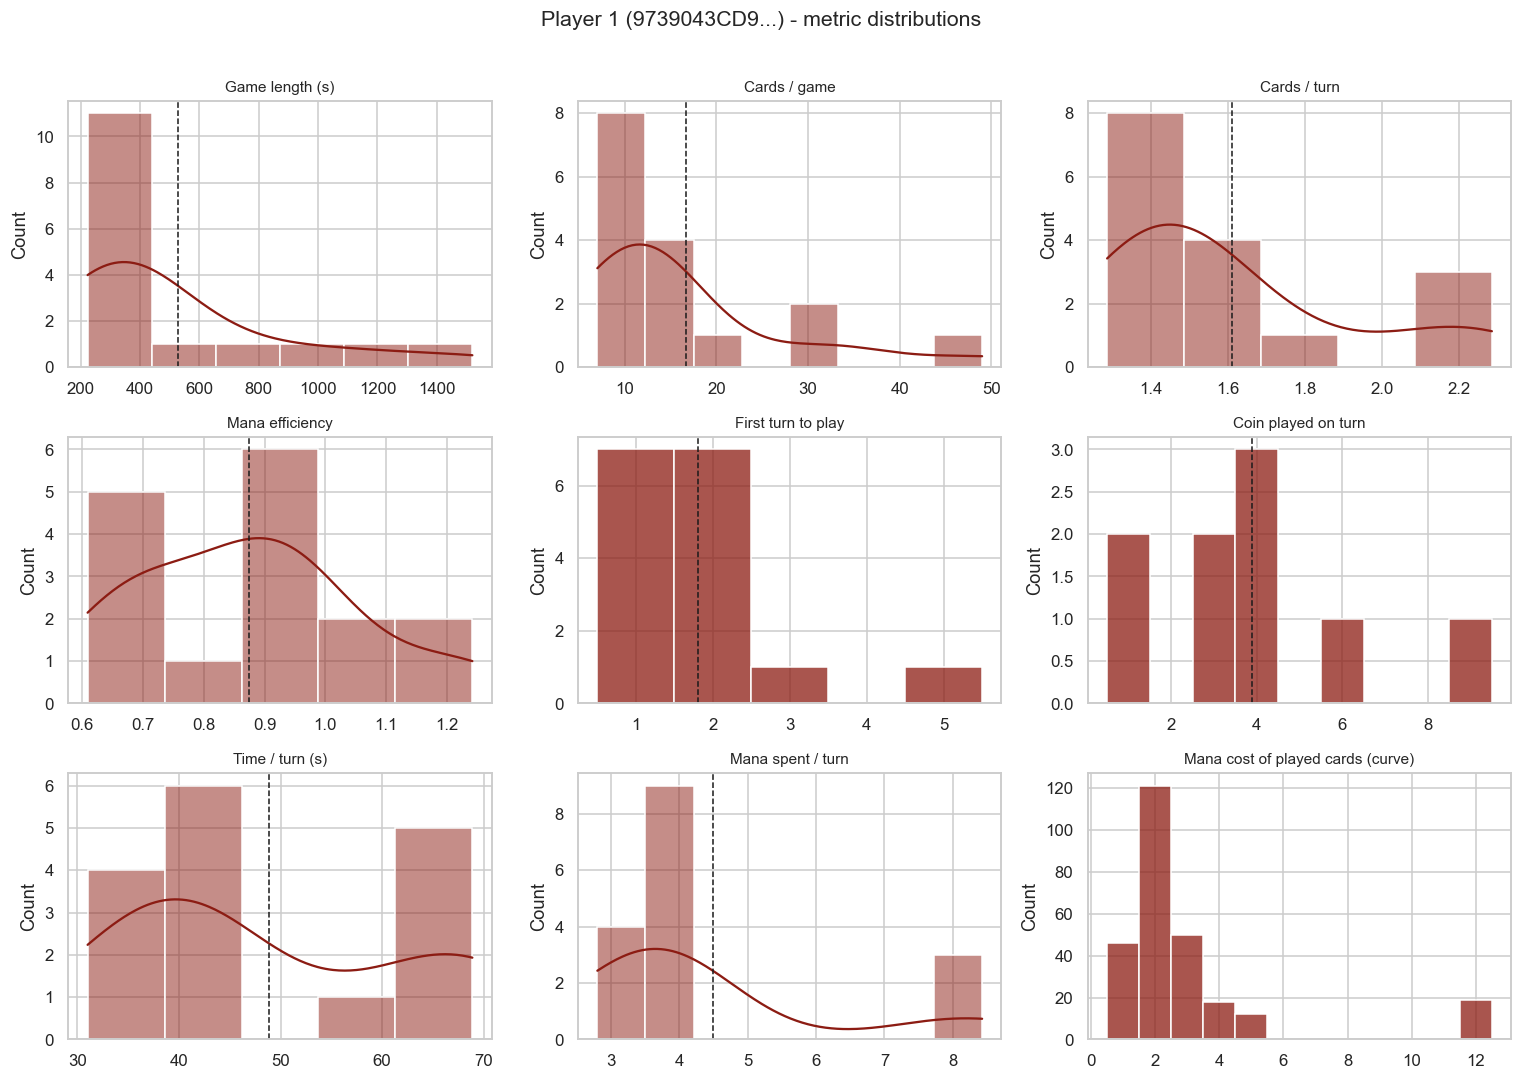

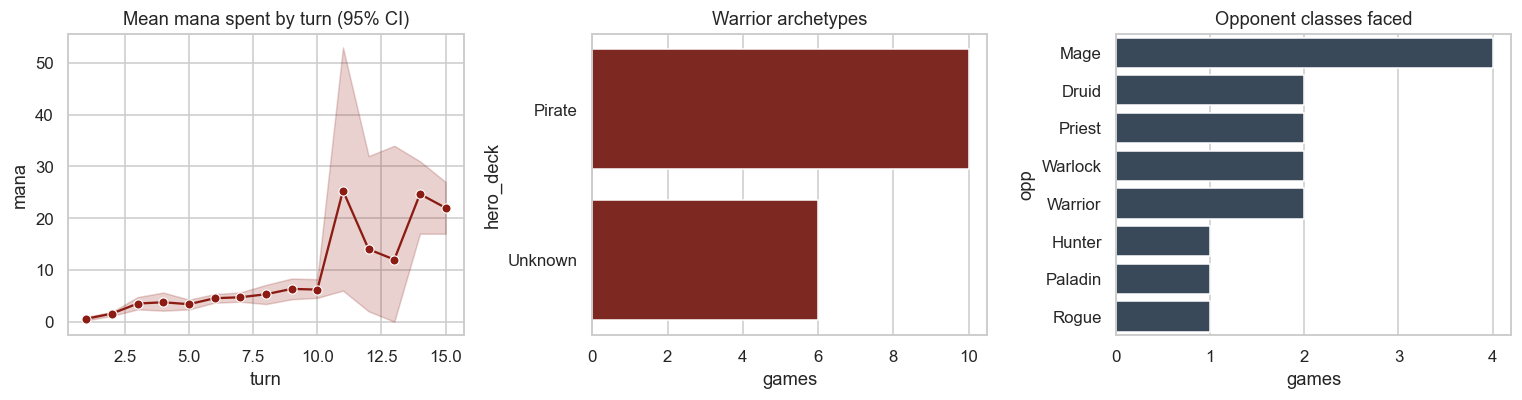

In [5]:
show_player(1)

### Player 2 of 10

### Player 2 / 10 &nbsp;·&nbsp; `0A89B858BCA8B415A945FF6F713FD15D`
**278** ranked Warrior games &nbsp;|&nbsp; peak rank **0**, avg **9.82**, median **12** &nbsp;|&nbsp; win **59.0%** &nbsp;|&nbsp; on the coin **48.2%**

*Archetypes:* Dragon (172), Tempo (35), Pirate (33), Unknown (27)  
*Vs classes:* Shaman (63), Warrior (49), Mage (30), Druid (30), Rogue (26)

,count,mean,std,min,25%,50%,75%,max
Game length (s),278.00,430.00,195.44,63.00,299.00,385.50,513.25,1392.00
Game length (turns),278.00,9.72,3.52,2.00,7.00,9.00,11.00,28.00
Cards / game,278.00,15.83,8.03,3.00,10.00,14.00,20.00,55.00
Cards / turn,278.00,1.60,0.30,0.86,1.38,1.57,1.83,2.22
Mana efficiency,278.00,0.91,0.12,0.53,0.84,0.91,0.96,1.67
First turn,278.00,1.50,0.60,1.00,1.00,1.00,2.00,5.00
Coin turn,127.00,3.02,2.64,1.00,1.00,2.00,4.00,13.00
Time / turn (s),278.00,43.90,10.34,23.50,38.59,42.50,47.63,152.75
Mana spent / turn,278.00,4.56,1.08,2.00,3.71,4.44,5.45,7.07
Mana cost of cards,4400.00,2.93,1.87,0.00,2.00,2.00,4.00,12.00


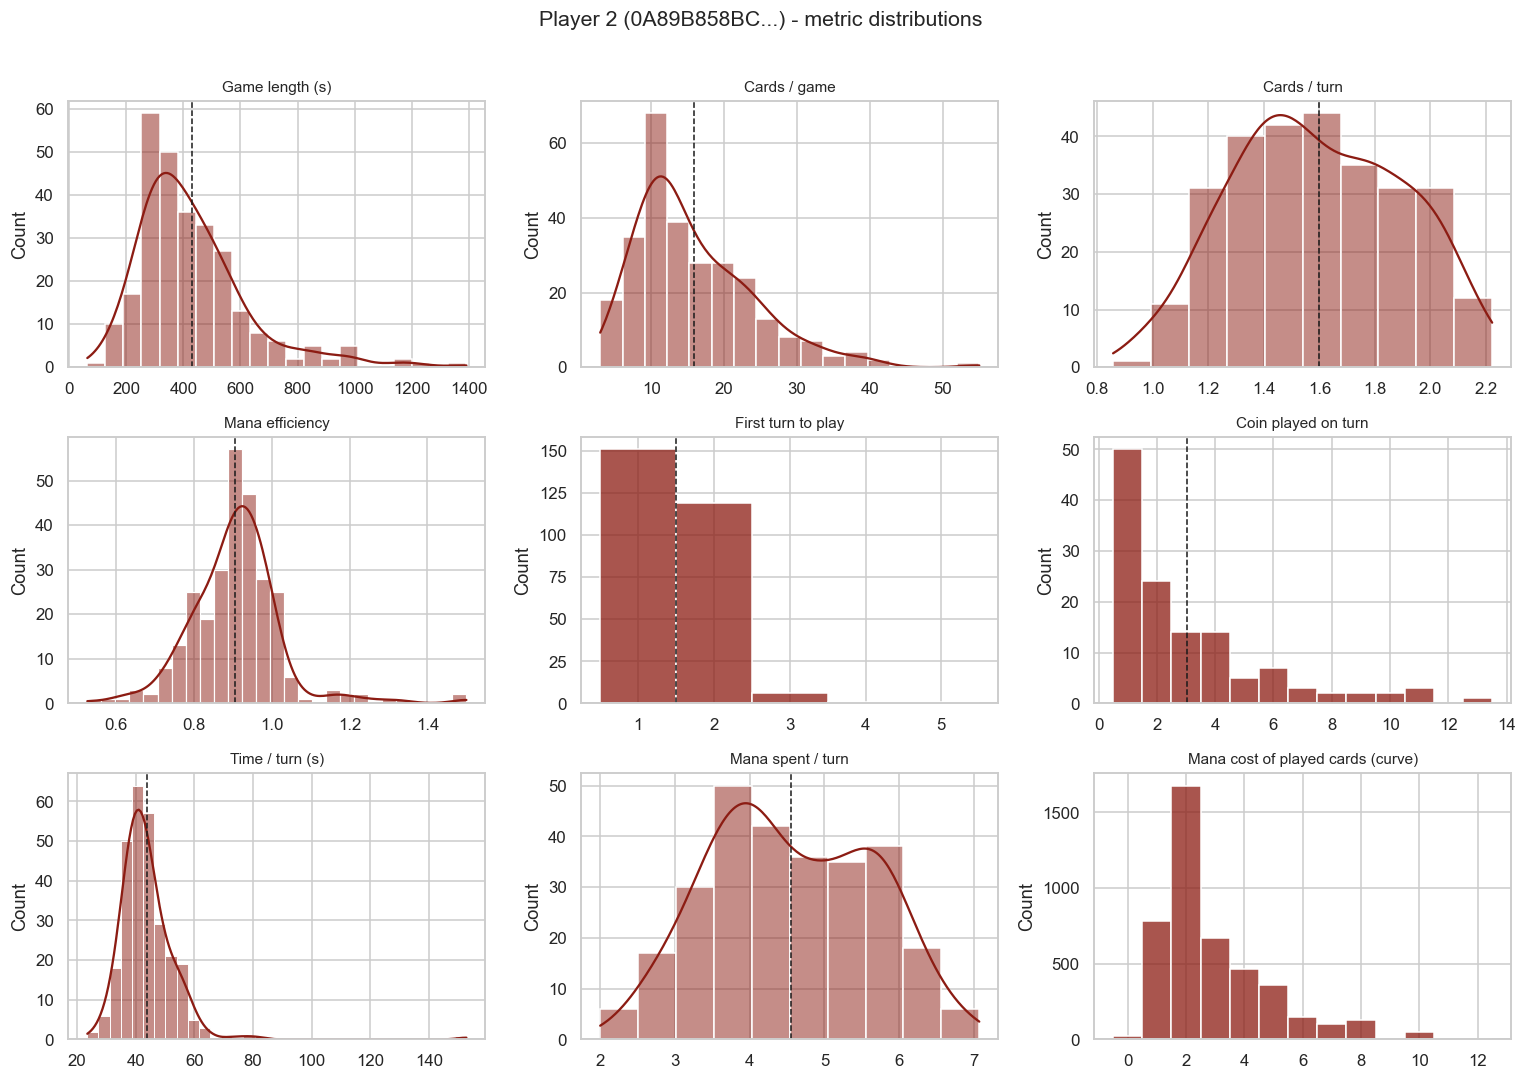

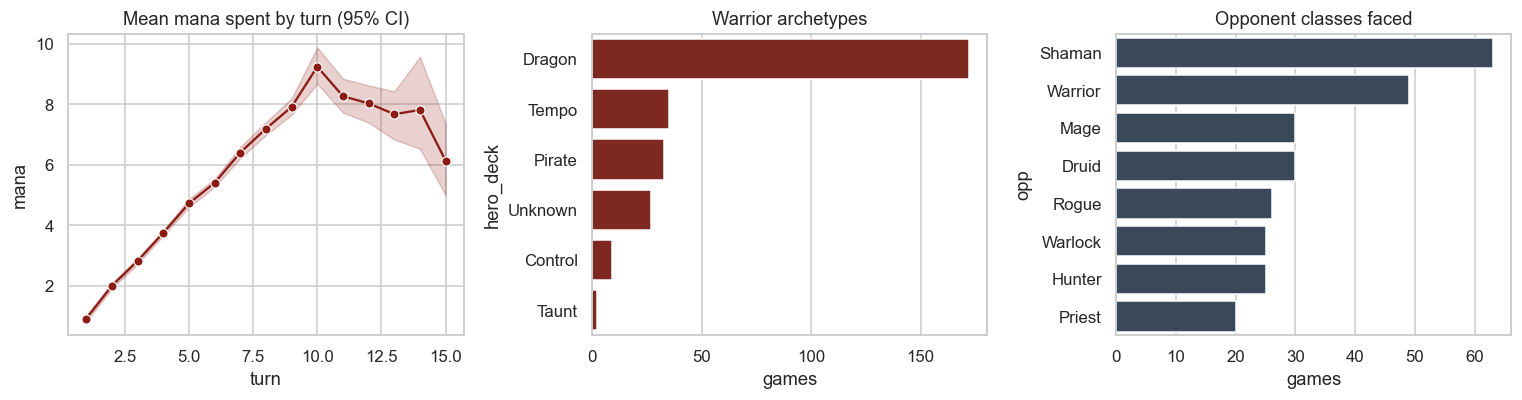

In [6]:
show_player(2)

### Player 3 of 10

### Player 3 / 10 &nbsp;·&nbsp; `A13B2797AAB3051007EF1DFE1461A43B`
**105** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **4.20**, median **4** &nbsp;|&nbsp; win **66.7%** &nbsp;|&nbsp; on the coin **47.6%**

*Archetypes:* Pirate (97), Unknown (8)  
*Vs classes:* Druid (37), Warrior (15), Paladin (12), Priest (9), Mage (9)

,count,mean,std,min,25%,50%,75%,max
Game length (s),105.00,287.55,133.47,94.00,209.00,256.00,338.00,1093.00
Game length (turns),105.00,6.82,2.21,2.00,5.00,7.00,8.00,13.00
Cards / game,105.00,11.24,5.69,0.00,8.00,10.00,14.00,34.00
Cards / turn,104.00,1.63,0.42,0.50,1.42,1.59,1.80,3.33
Mana efficiency,104.00,1.02,0.22,0.58,0.88,1.00,1.10,2.03
First turn,104.00,1.19,0.40,1.00,1.00,1.00,1.00,2.00
Coin turn,52.00,1.83,1.00,1.00,1.00,2.00,2.00,6.00
Time / turn (s),105.00,42.57,13.49,17.08,35.50,40.71,45.00,136.62
Mana spent / turn,104.00,3.96,1.22,1.00,3.38,3.80,4.43,8.89
Mana cost of cards,1179.00,2.47,1.30,1.00,1.00,2.00,3.00,5.00


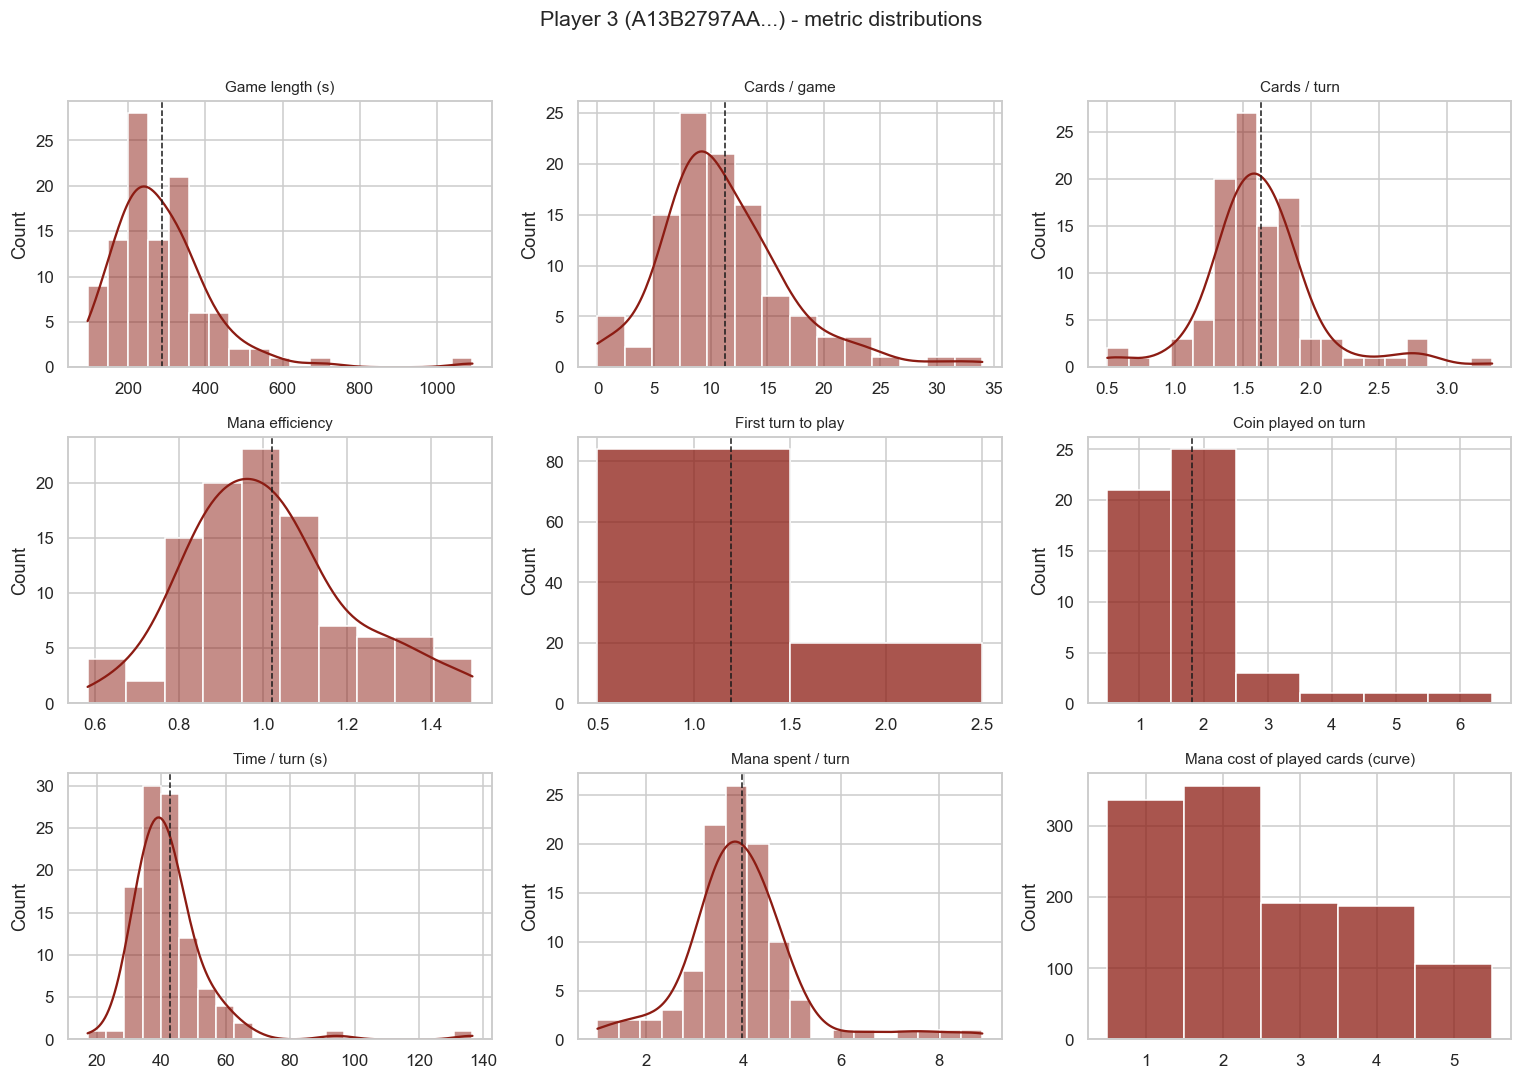

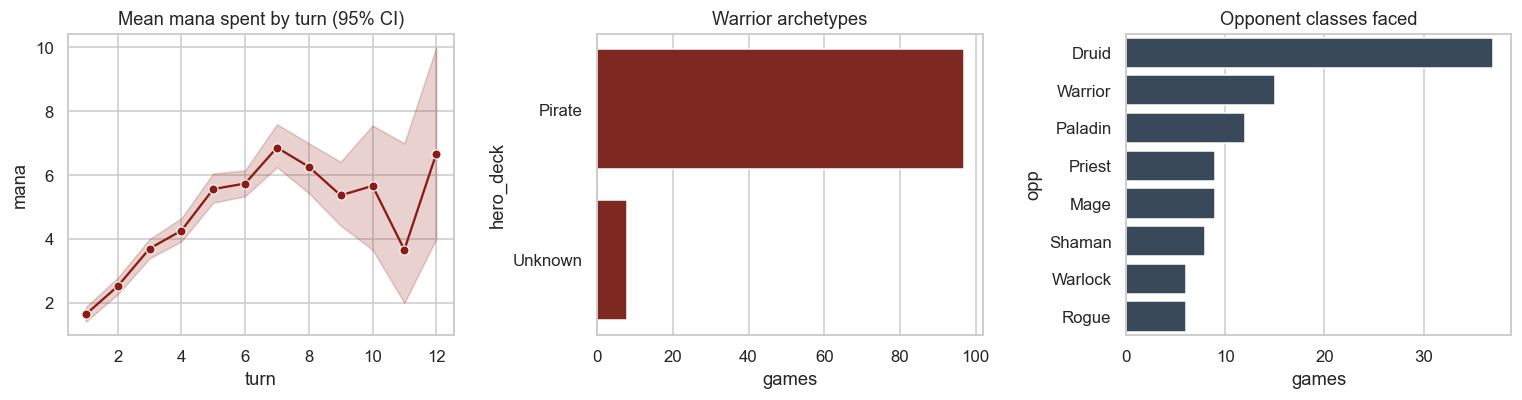

In [7]:
show_player(3)

### Player 4 of 10

### Player 4 / 10 &nbsp;·&nbsp; `2BBAF573183F94724B51C438E2929772`
**70** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **5.30**, median **4** &nbsp;|&nbsp; win **50.0%** &nbsp;|&nbsp; on the coin **48.6%**

*Archetypes:* Control (33), Unknown (16), Taunt (15), Pirate (6)  
*Vs classes:* Warrior (14), Paladin (13), Hunter (11), Rogue (10), Mage (6)

,count,mean,std,min,25%,50%,75%,max
Game length (s),70.00,481.70,236.55,48.00,307.00,428.00,632.75,1093.00
Game length (turns),70.00,11.24,4.75,1.00,8.00,11.00,15.00,23.00
Cards / game,70.00,19.23,10.40,1.00,11.00,18.50,26.00,48.00
Cards / turn,70.00,1.65,0.39,0.50,1.44,1.69,1.86,3.20
Mana efficiency,70.00,0.88,0.15,0.33,0.80,0.89,0.95,1.44
First turn,70.00,1.20,0.44,0.00,1.00,1.00,1.00,2.00
Coin turn,32.00,3.16,1.90,1.00,2.00,3.00,4.00,9.00
Time / turn (s),70.00,42.54,7.80,17.88,37.58,41.32,48.10,61.87
Mana spent / turn,70.00,4.82,1.52,0.50,3.78,5.15,5.63,10.27
Mana cost of cards,1346.00,3.02,1.75,0.00,2.00,2.00,4.00,9.00


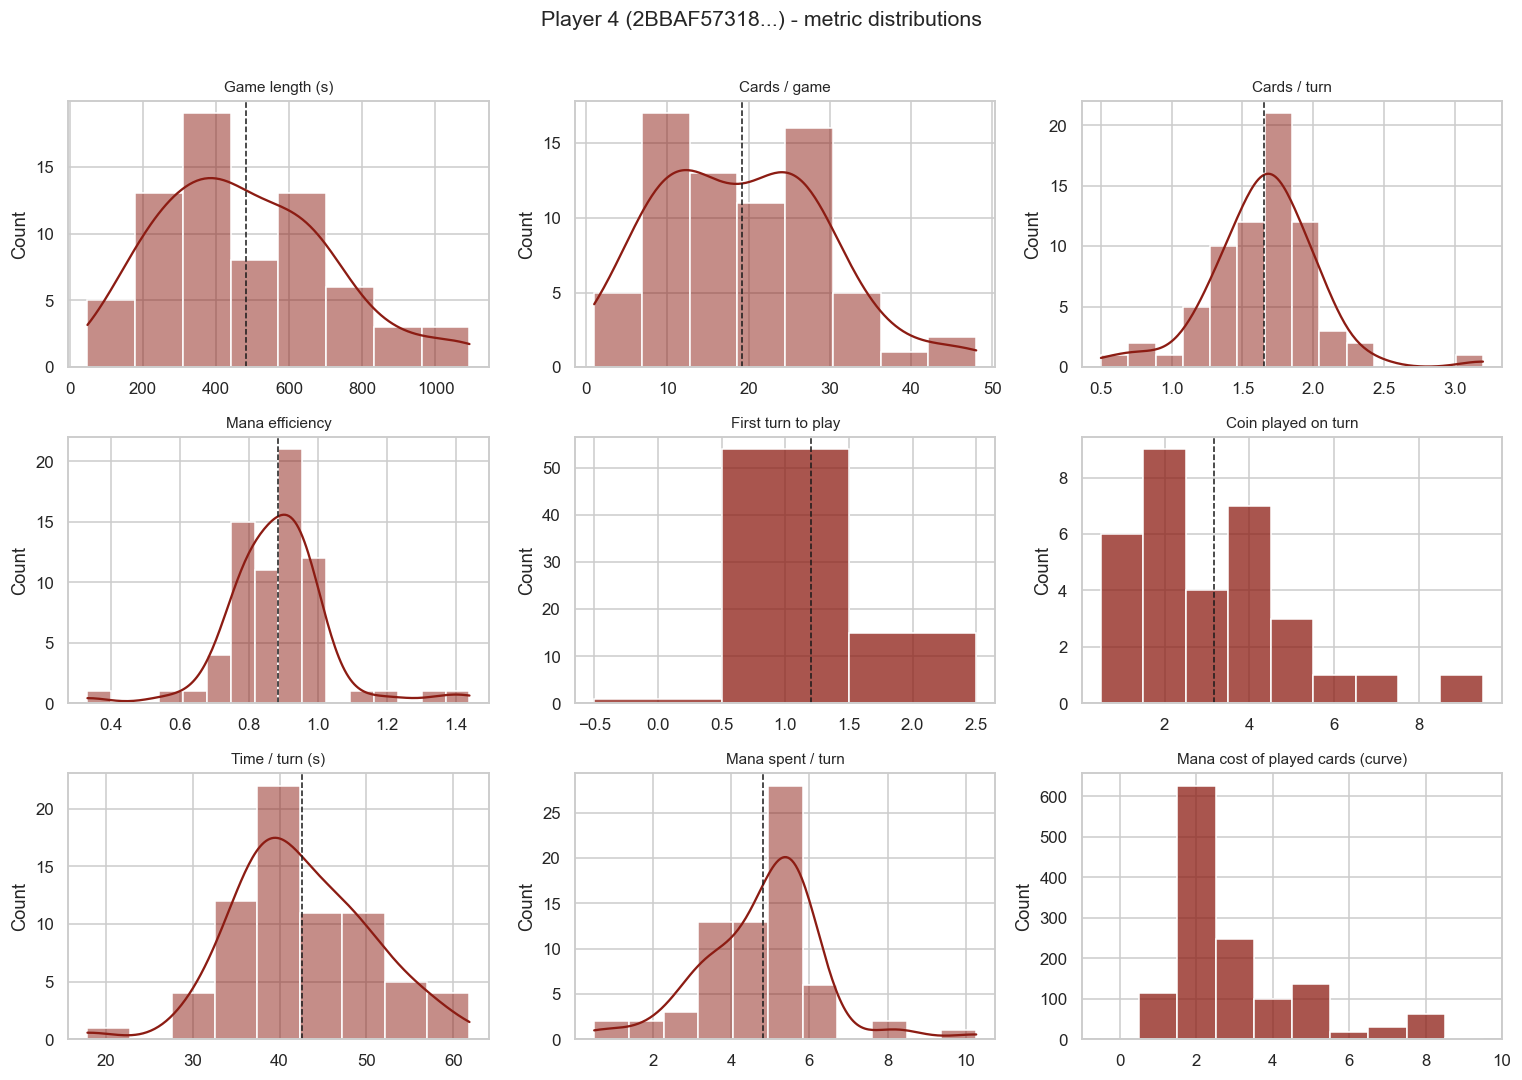

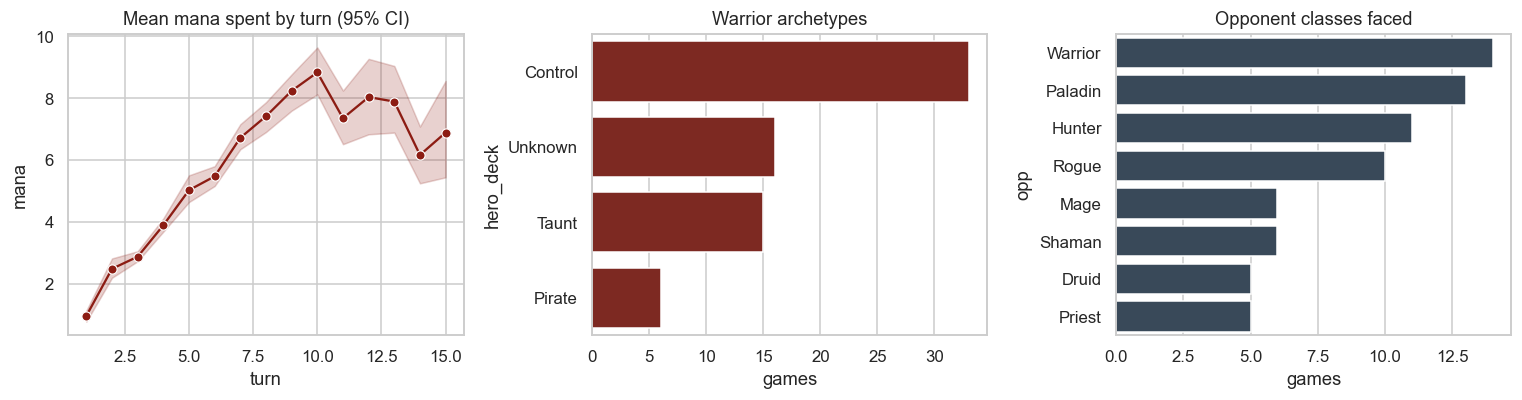

In [8]:
show_player(4)

### Player 5 of 10

### Player 5 / 10 &nbsp;·&nbsp; `8863CAB9F29423EC070294F932BCCACE`
**256** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **6.12**, median **5** &nbsp;|&nbsp; win **51.6%** &nbsp;|&nbsp; on the coin **51.2%**

*Archetypes:* Pirate (182), Dragon (33), Unknown (31), Control (8)  
*Vs classes:* Shaman (67), Warrior (55), Rogue (30), Priest (25), Warlock (25)

,count,mean,std,min,25%,50%,75%,max
Game length (s),256.00,289.44,124.87,46.00,211.75,272.00,341.75,863.00
Game length (turns),251.00,7.35,2.77,1.00,6.00,7.00,8.00,20.00
Cards / game,251.00,12.10,5.63,1.00,8.00,11.00,15.00,41.00
Cards / turn,251.00,1.67,0.29,0.80,1.50,1.67,1.85,3.00
Mana efficiency,251.00,0.99,0.19,0.53,0.89,0.97,1.05,2.09
First turn,251.00,1.24,0.43,1.00,1.00,1.00,1.00,2.00
Coin turn,125.00,2.66,1.63,1.00,1.00,2.00,4.00,8.00
Time / turn (s),251.00,39.69,9.07,24.80,34.39,38.00,43.08,95.89
Mana spent / turn,251.00,3.91,0.92,1.00,3.40,3.86,4.43,6.31
Mana cost of cards,3038.00,2.45,1.48,0.00,1.00,2.00,3.00,12.00


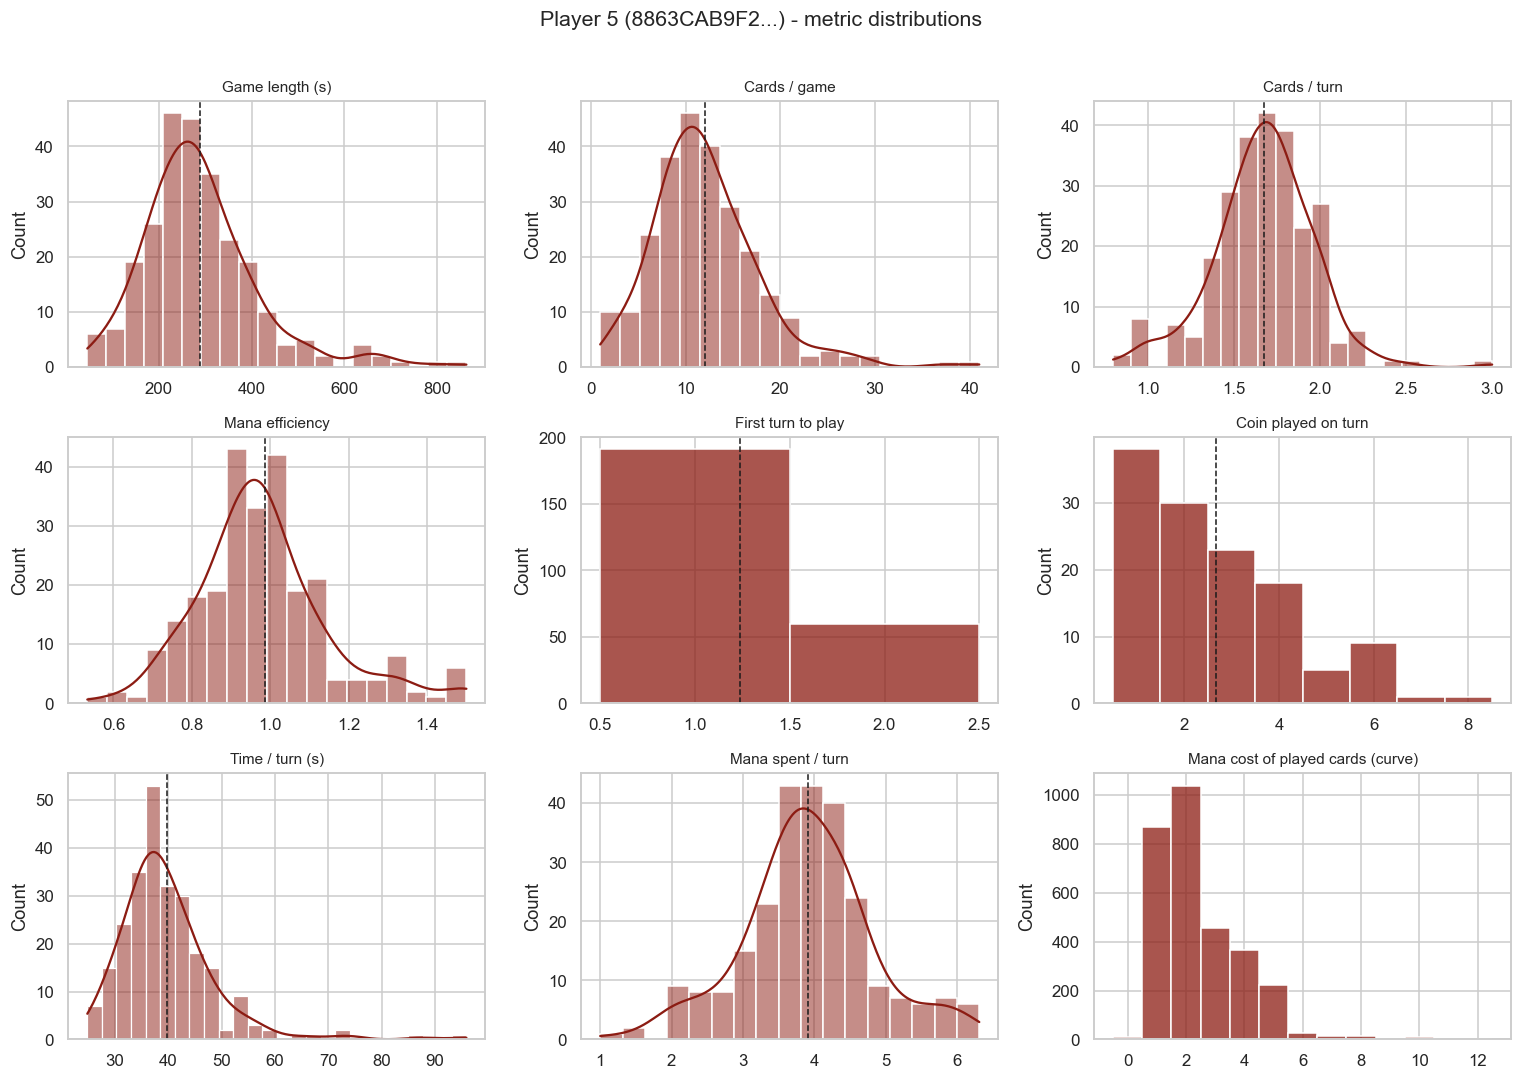

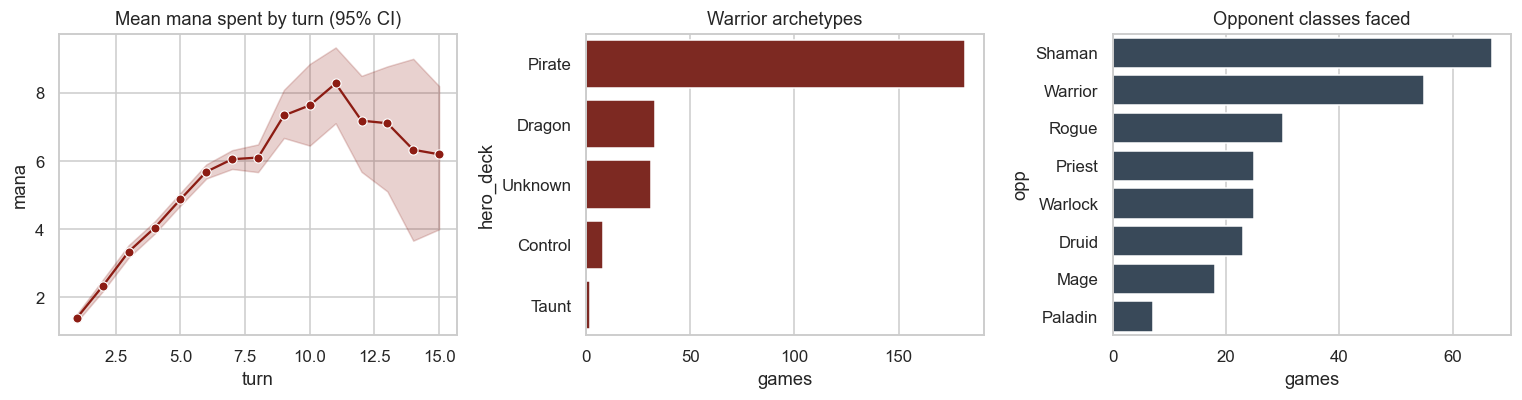

In [9]:
show_player(5)

### Player 6 of 10

### Player 6 / 10 &nbsp;·&nbsp; `FAB1105726228BB60FDC9E2EA54CEE62`
**103** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **6.16**, median **3** &nbsp;|&nbsp; win **64.1%** &nbsp;|&nbsp; on the coin **57.3%**

*Archetypes:* Pirate (76), Dragon (21), Control (3), Unknown (2)  
*Vs classes:* Warrior (26), Warlock (15), Rogue (14), Shaman (13), Hunter (10)

,count,mean,std,min,25%,50%,75%,max
Game length (s),103.00,337.91,118.72,125.00,262.00,325.00,391.00,704.00
Game length (turns),103.00,8.04,2.41,3.00,7.00,8.00,9.00,18.00
Cards / game,103.00,13.08,4.97,3.00,10.00,12.00,15.50,30.00
Cards / turn,103.00,1.65,0.24,1.00,1.50,1.67,1.83,2.33
Mana efficiency,103.00,0.95,0.14,0.67,0.86,0.94,1.00,1.57
First turn,103.00,1.24,0.43,1.00,1.00,1.00,1.00,2.00
Coin turn,55.00,2.42,2.17,1.00,1.50,2.00,3.00,16.00
Time / turn (s),103.00,41.94,7.29,19.33,37.50,40.43,45.64,66.00
Mana spent / turn,103.00,4.15,0.84,2.00,3.65,4.14,4.60,6.36
Mana cost of cards,1347.00,2.60,1.55,1.00,1.00,2.00,3.00,10.00


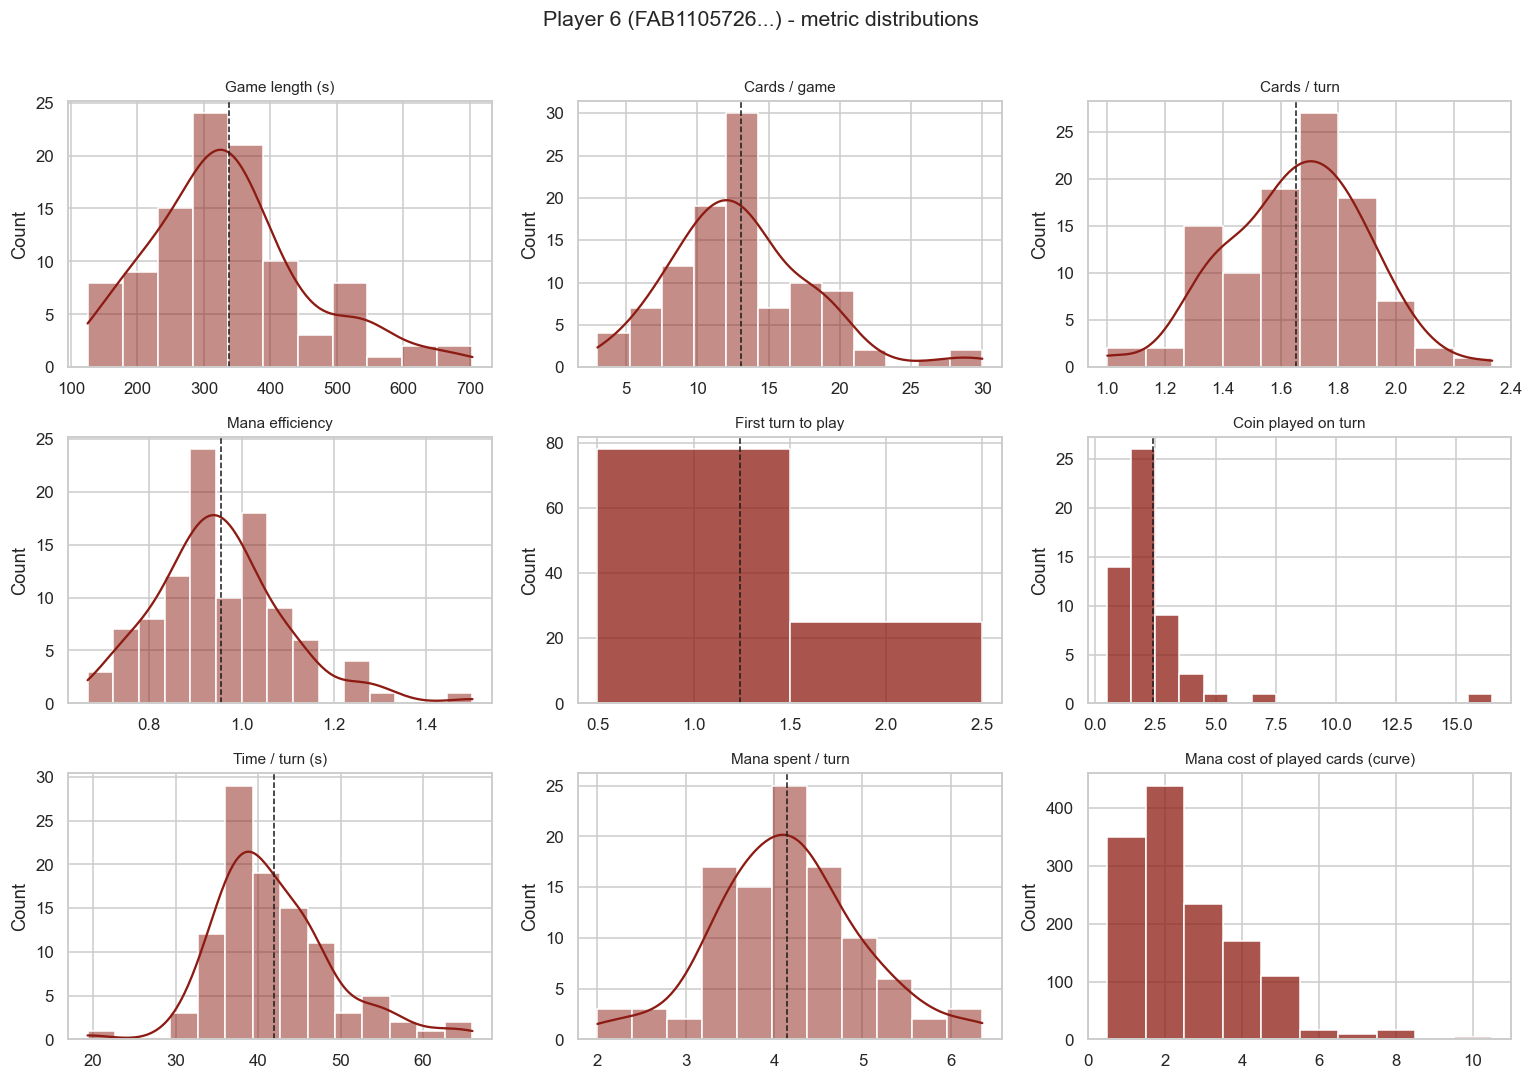

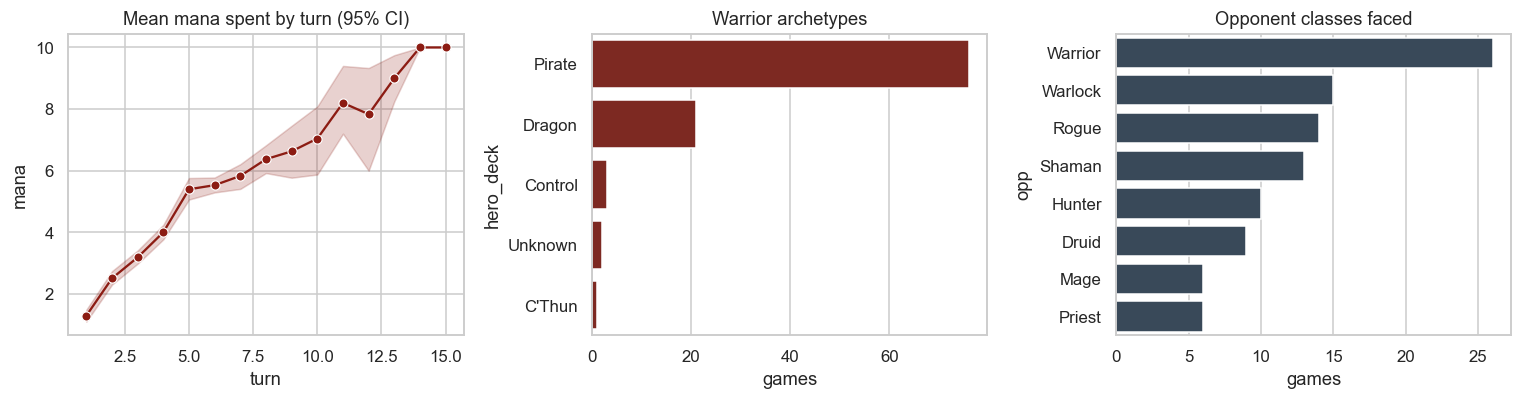

In [10]:
show_player(6)

### Player 7 of 10

### Player 7 / 10 &nbsp;·&nbsp; `E8F1B76105997B26404B2A58BA5319E1`
**124** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **6.22**, median **5** &nbsp;|&nbsp; win **58.9%** &nbsp;|&nbsp; on the coin **55.6%**

*Archetypes:* Pirate (104), Unknown (20)  
*Vs classes:* Druid (41), Mage (16), Warrior (15), Paladin (12), Hunter (12)

,count,mean,std,min,25%,50%,75%,max
Game length (s),124.00,261.42,103.46,52.00,192.00,264.00,316.00,654.00
Game length (turns),124.00,6.31,2.30,1.00,5.00,6.00,8.00,12.00
Cards / game,124.00,9.57,4.66,0.00,6.00,9.00,13.00,23.00
Cards / turn,121.00,1.56,0.28,0.67,1.40,1.57,1.75,3.00
Mana efficiency,121.00,1.03,0.21,0.70,0.91,1.00,1.10,2.00
First turn,121.00,1.30,0.46,1.00,1.00,1.00,2.00,2.00
Coin turn,63.00,2.03,1.26,1.00,1.00,2.00,2.00,7.00
Time / turn (s),124.00,42.73,11.25,27.00,36.67,40.43,44.79,102.00
Mana spent / turn,121.00,3.64,0.87,1.50,3.17,3.86,4.14,5.80
Mana cost of cards,1186.00,2.43,1.26,1.00,1.00,2.00,3.00,5.00


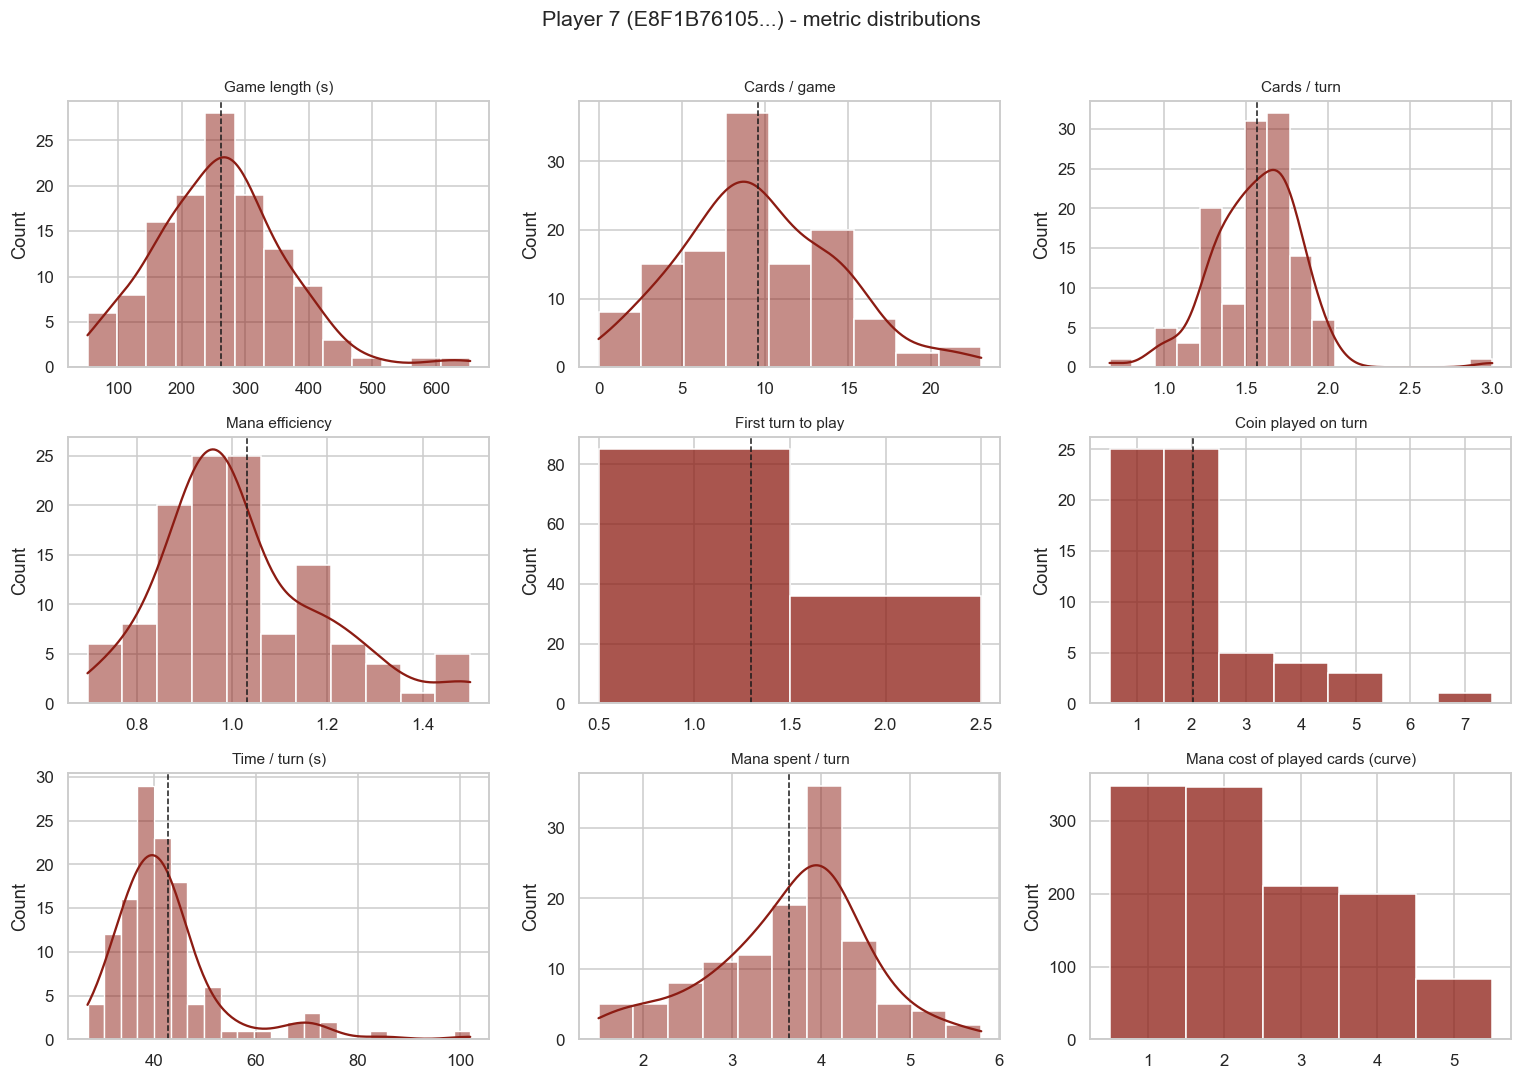

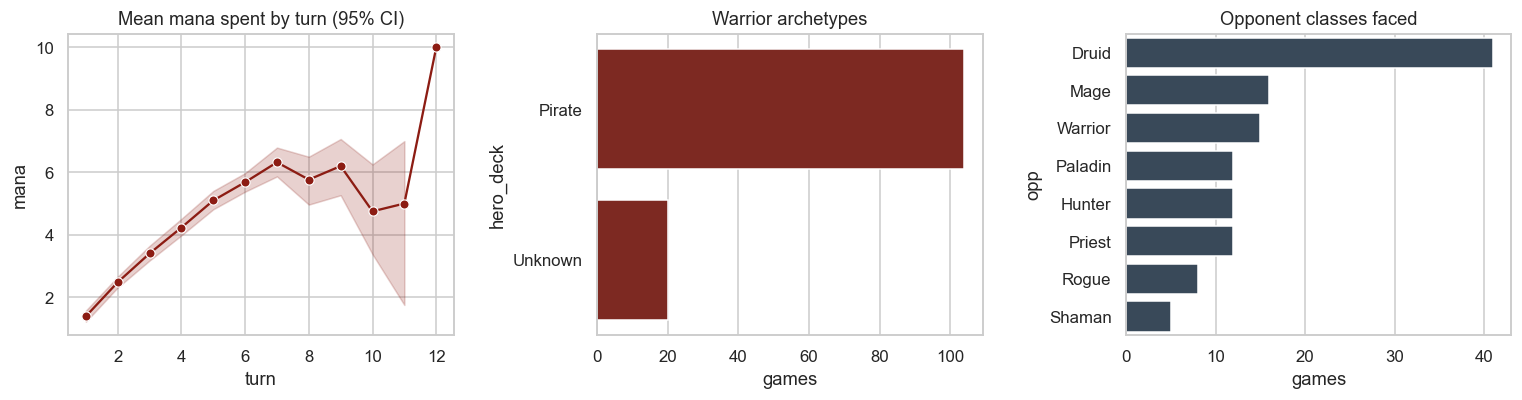

In [11]:
show_player(7)

### Player 8 of 10

### Player 8 / 10 &nbsp;·&nbsp; `AFC4C2FB8C6A089D351EBB921A3EF663`
**459** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **6.58**, median **5** &nbsp;|&nbsp; win **52.1%** &nbsp;|&nbsp; on the coin **49.2%**

*Archetypes:* Pirate (187), Unknown (142), Dragon (121), Control (7)  
*Vs classes:* Shaman (123), Warrior (85), Warlock (61), Rogue (51), Druid (45)

,count,mean,std,min,25%,50%,75%,max
Game length (s),416.00,446.69,210.36,144.00,310.00,399.50,528.00,2156.00
Game length (turns),416.00,8.53,2.70,3.00,7.00,8.00,10.00,21.00
Cards / game,416.00,13.52,6.18,4.00,9.00,12.00,17.00,41.00
Cards / turn,416.00,1.60,0.34,0.71,1.40,1.62,1.80,3.30
Mana efficiency,416.00,0.91,0.17,0.43,0.80,0.90,1.00,1.84
First turn,416.00,1.34,0.52,1.00,1.00,1.00,2.00,3.00
Coin turn,211.00,2.50,1.54,1.00,1.00,2.00,3.00,9.00
Time / turn (s),416.00,52.17,19.78,32.60,43.89,49.50,55.74,308.00
Mana spent / turn,416.00,4.12,0.93,2.00,3.50,4.00,4.54,10.30
Mana cost of cards,5625.00,2.64,1.56,0.00,2.00,2.00,4.00,10.00


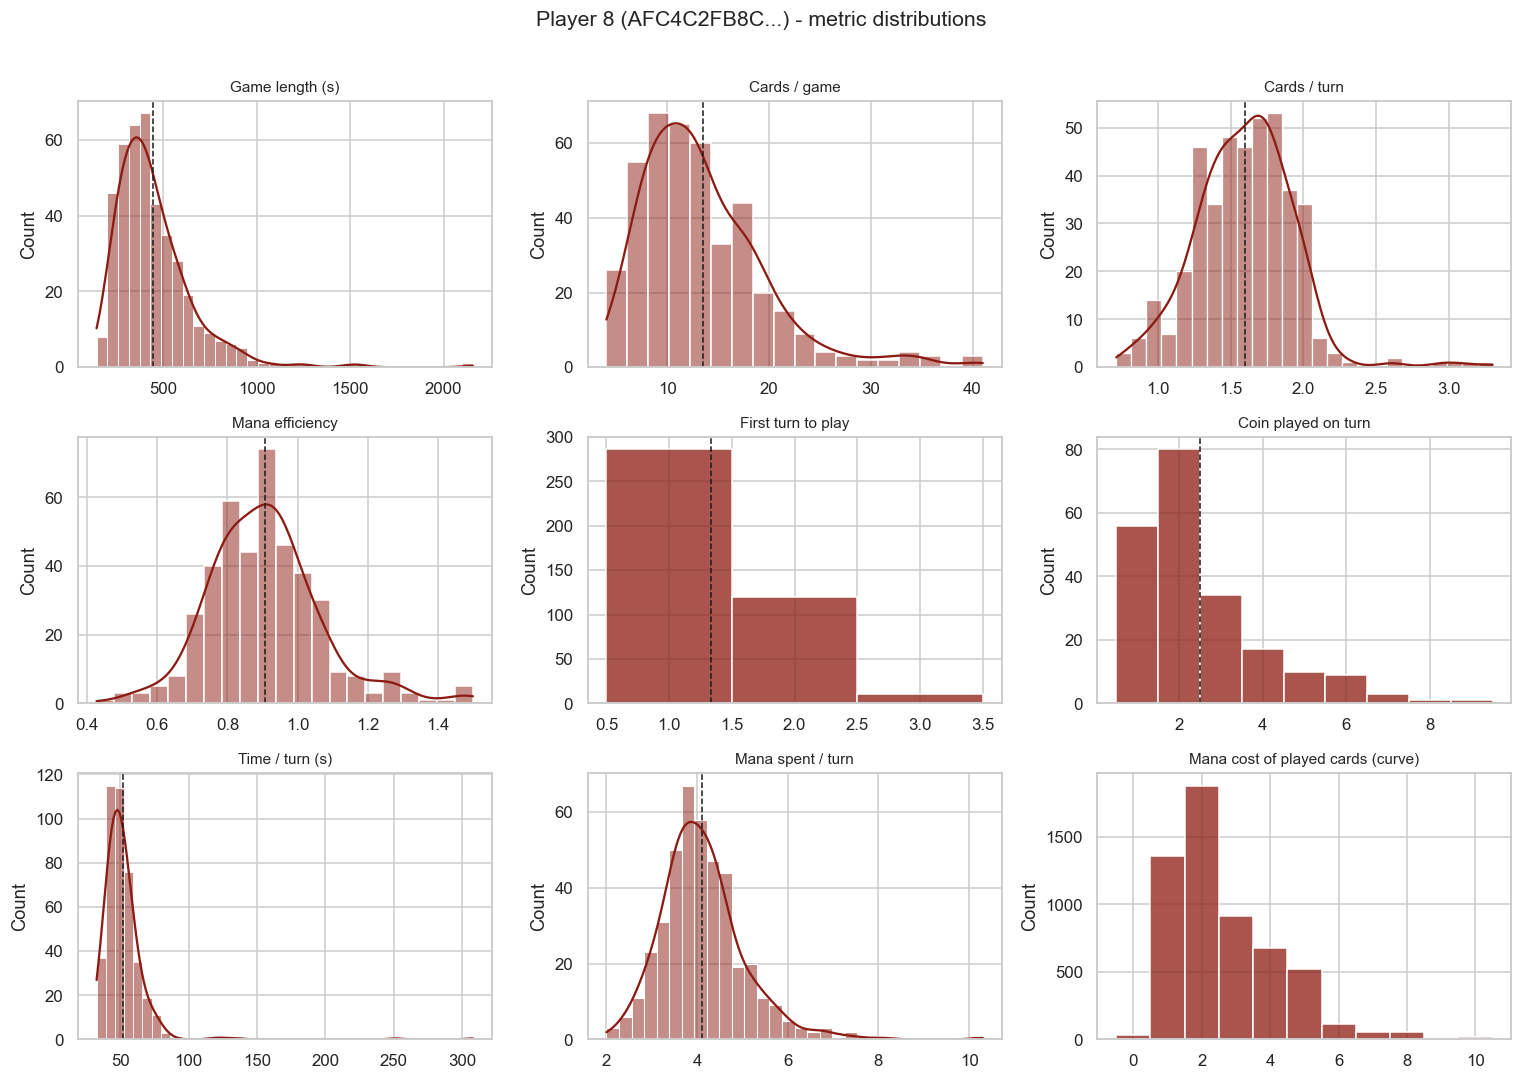

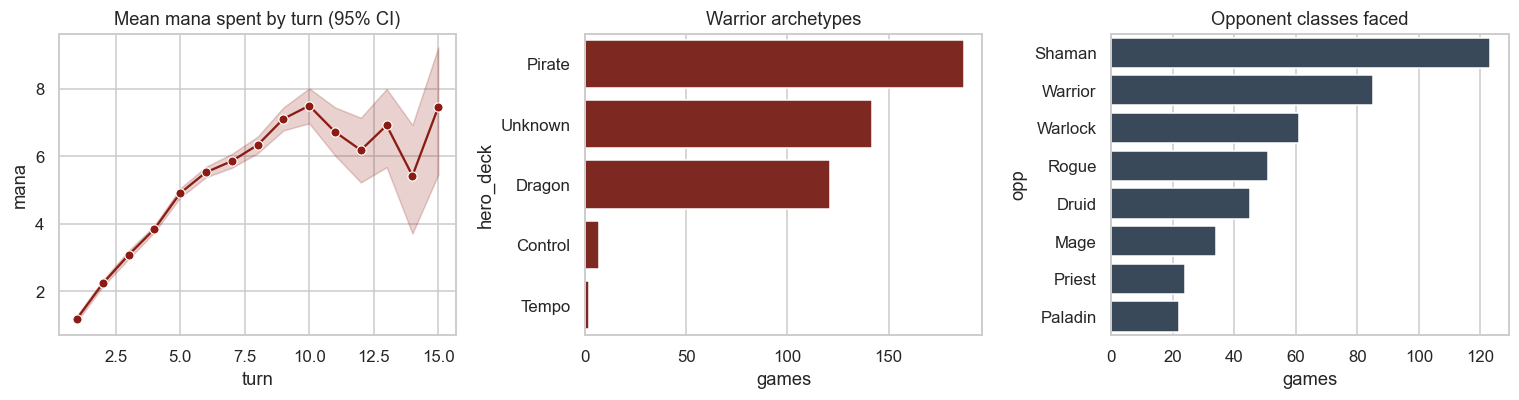

In [12]:
show_player(8)

### Player 9 of 10

### Player 9 / 10 &nbsp;·&nbsp; `69A338D02ADBCA97E28846EDEF41C26B`
**440** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **6.62**, median **5** &nbsp;|&nbsp; win **60.7%** &nbsp;|&nbsp; on the coin **47.7%**

*Archetypes:* Dragon (198), Pirate (131), Unknown (53), Control (50)  
*Vs classes:* Warrior (111), Shaman (78), Warlock (52), Druid (50), Mage (36)

,count,mean,std,min,25%,50%,75%,max
Game length (s),440.00,371.03,175.02,63.00,266.00,335.00,422.00,1611.00
Game length (turns),440.00,9.41,3.92,2.00,7.00,9.00,11.00,35.00
Cards / game,440.00,14.45,7.62,0.00,10.00,13.00,17.00,55.00
Cards / turn,439.00,1.54,0.30,0.50,1.33,1.50,1.71,2.67
Mana efficiency,439.00,0.89,0.15,0.50,0.81,0.87,0.97,1.57
First turn,439.00,1.50,0.56,1.00,1.00,1.00,2.00,4.00
Coin turn,200.00,3.16,1.91,1.00,2.00,3.00,4.00,11.00
Time / turn (s),440.00,39.43,8.09,17.58,34.36,37.81,42.91,102.70
Mana spent / turn,439.00,4.29,0.95,1.00,3.67,4.22,4.81,7.58
Mana cost of cards,6358.00,2.90,1.81,0.00,2.00,2.00,4.00,12.00


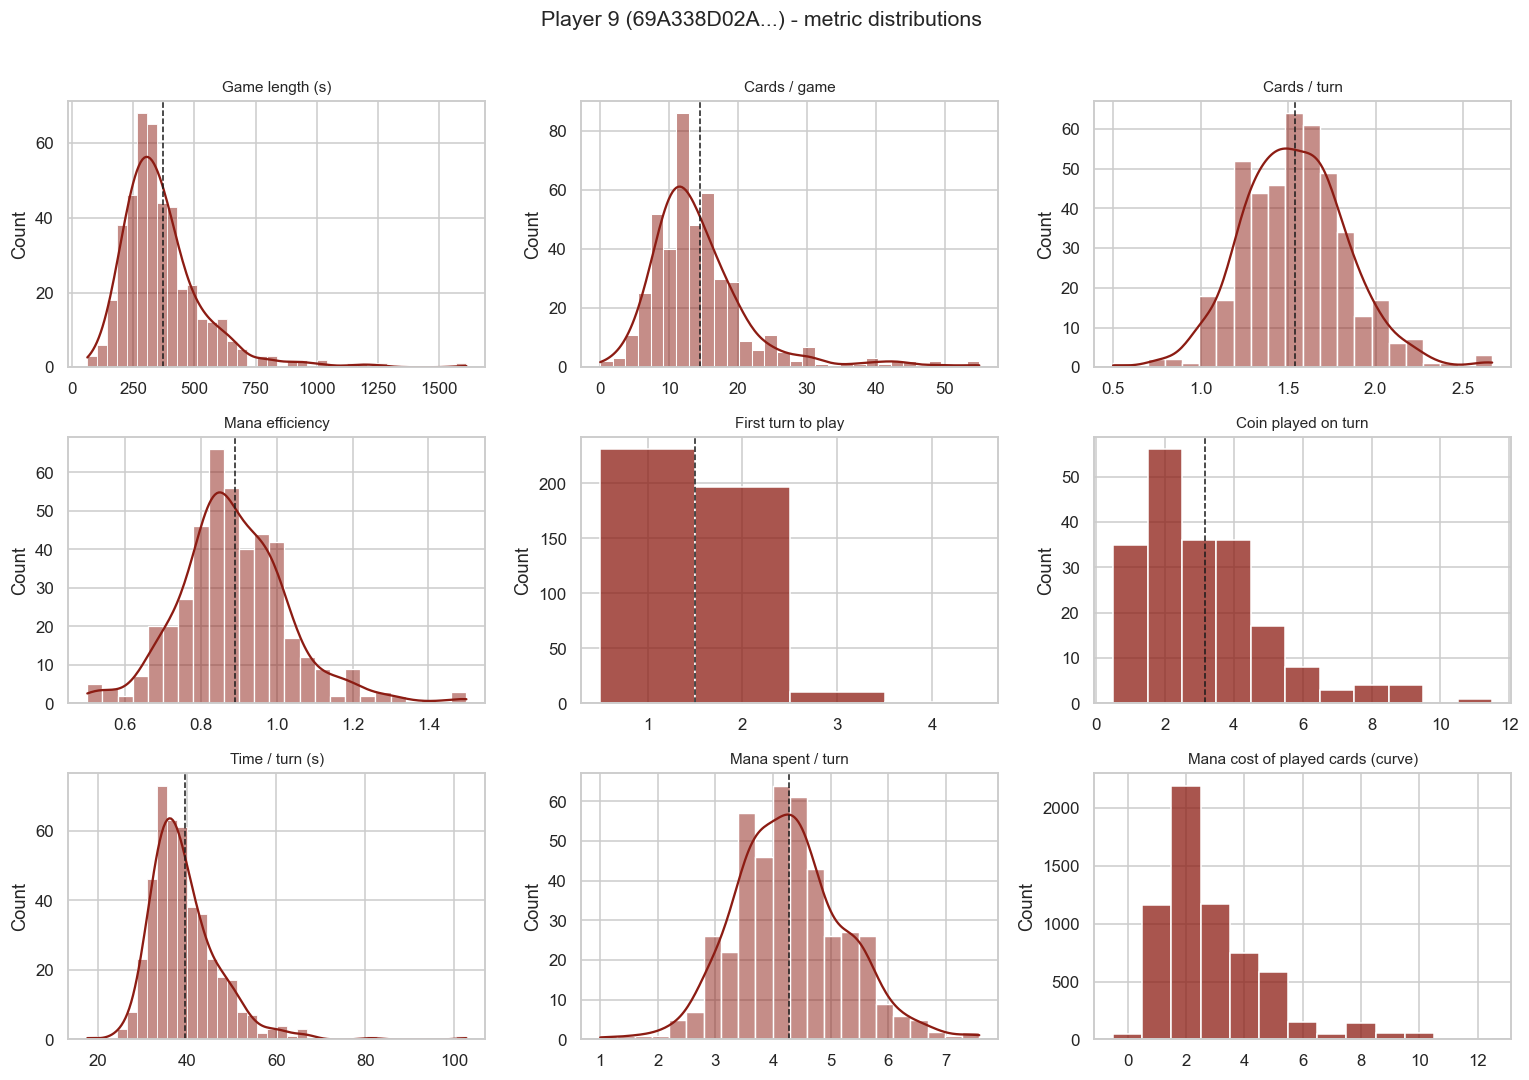

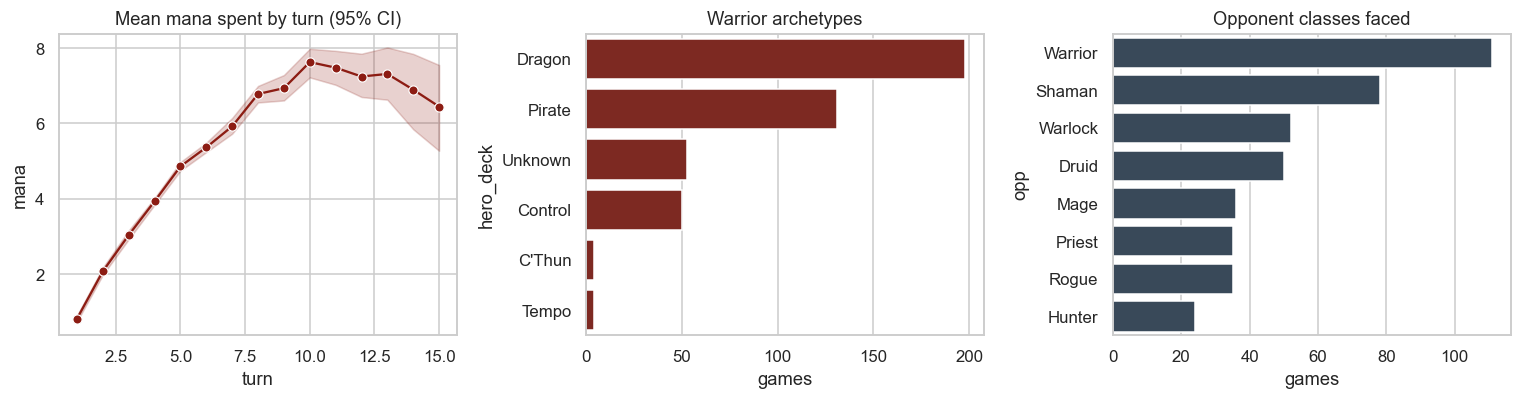

In [13]:
show_player(9)

### Player 10 of 10

### Player 10 / 10 &nbsp;·&nbsp; `B5C3A54045A0E55B6A14D520CB1FDC7B`
**607** ranked Warrior games &nbsp;|&nbsp; peak rank **1**, avg **6.72**, median **5** &nbsp;|&nbsp; win **59.3%** &nbsp;|&nbsp; on the coin **49.6%**

*Archetypes:* Pirate (489), Unknown (87), Taunt (11), Control (10)  
*Vs classes:* Shaman (139), Warrior (114), Druid (87), Rogue (69), Mage (55)

,count,mean,std,min,25%,50%,75%,max
Game length (s),607.00,320.59,155.46,68.00,224.50,292.00,374.50,1940.00
Game length (turns),607.00,7.16,2.60,1.00,6.00,7.00,8.00,30.00
Cards / game,607.00,11.37,5.17,0.00,8.00,11.00,14.00,55.00
Cards / turn,605.00,1.61,0.28,0.50,1.43,1.64,1.80,3.00
Mana efficiency,605.00,0.98,0.17,0.35,0.89,0.97,1.06,2.00
First turn,605.00,1.26,0.45,1.00,1.00,1.00,2.00,4.00
Coin turn,286.00,2.69,1.56,1.00,2.00,2.00,3.00,9.00
Time / turn (s),607.00,44.92,17.76,22.50,37.33,42.80,48.67,367.00
Mana spent / turn,605.00,3.85,0.83,1.00,3.33,3.86,4.38,6.82
Mana cost of cards,6900.00,2.47,1.39,0.00,1.00,2.00,3.00,10.00


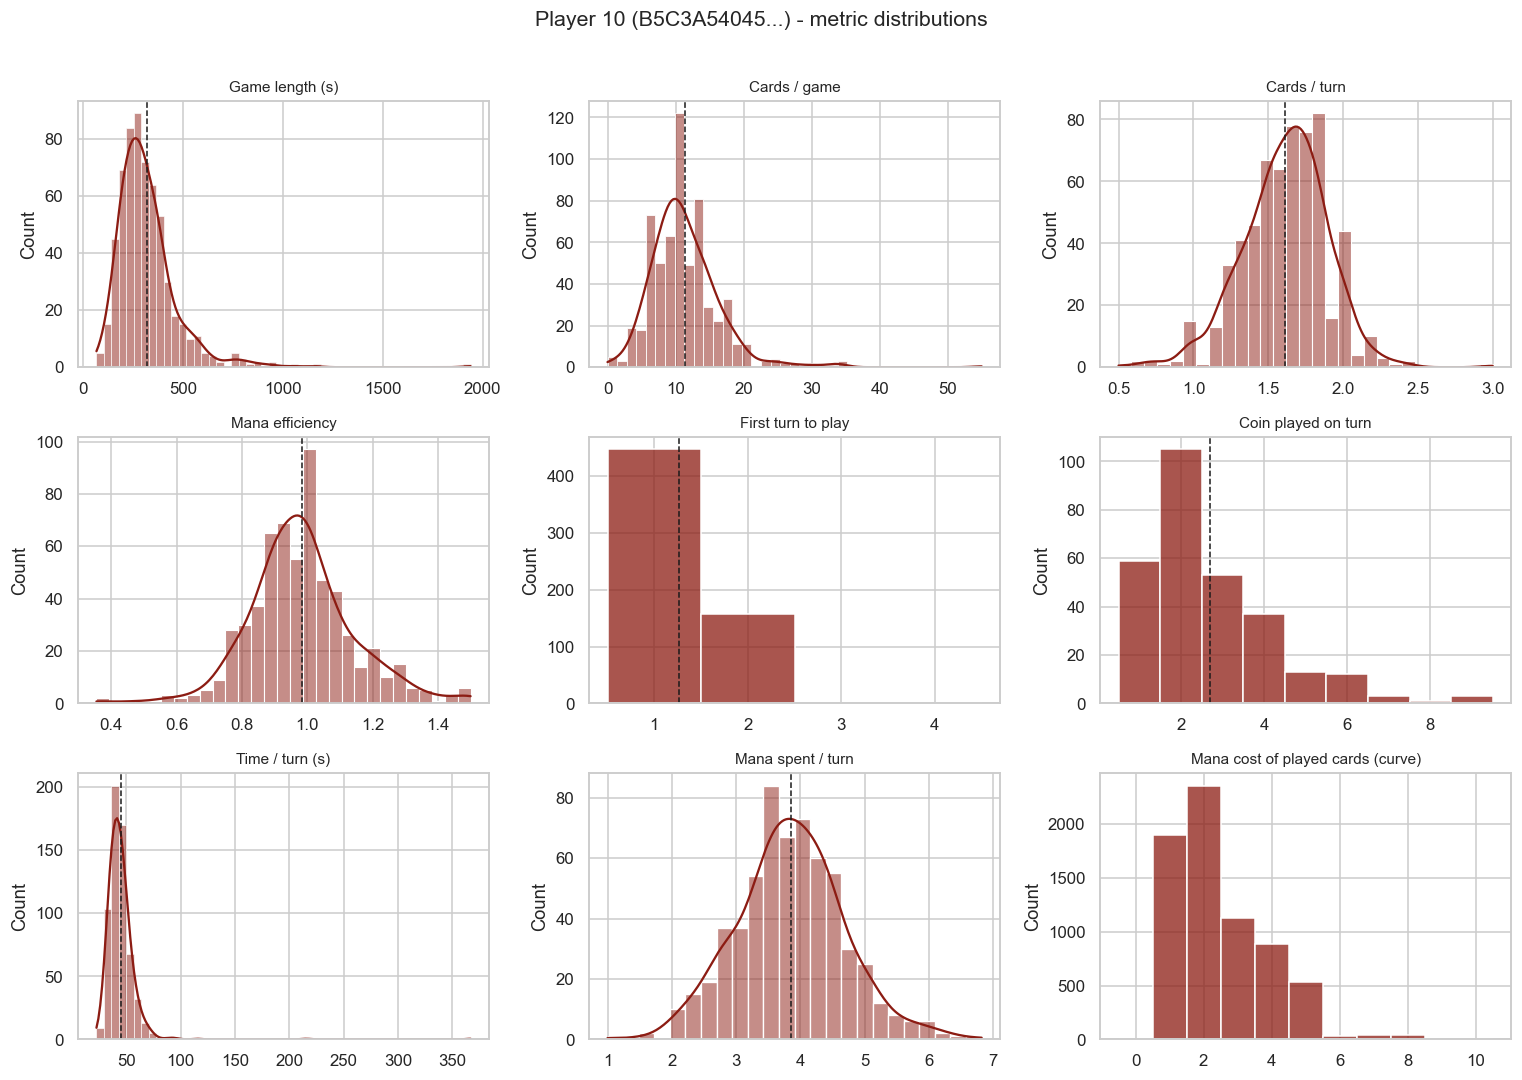

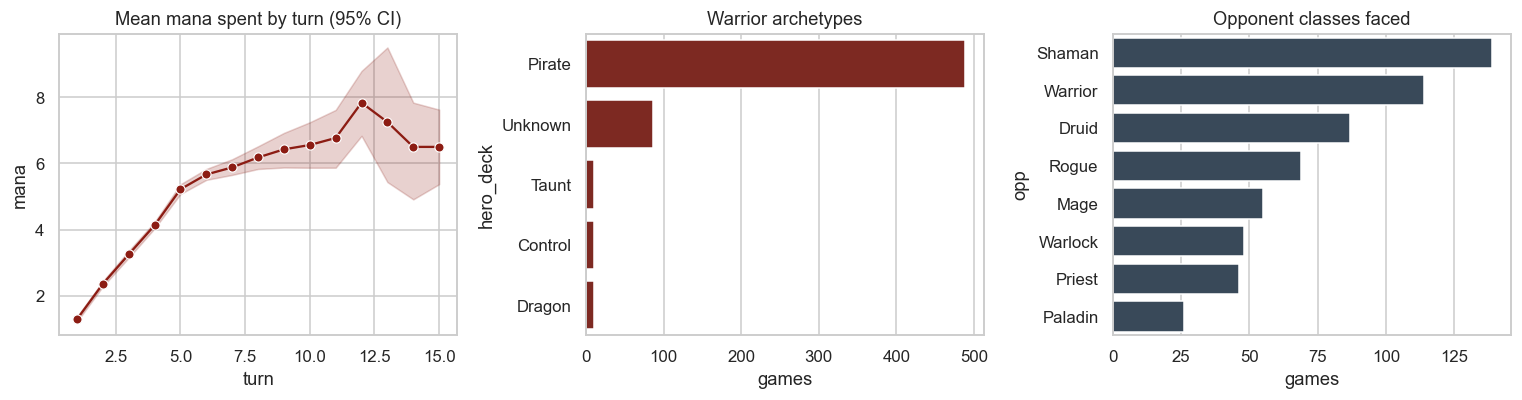

In [14]:
show_player(10)

---
## 6 · Cross-player comparison

,win%,Game length (s),Cards / game,Cards / turn,Mana efficiency,First turn,Coin turn,Time / turn (s),Mana spent / turn
player,,,,,,,,,
1,56.25,528.06,16.62,1.61,0.87,1.81,3.89,48.84,4.49
2,58.99,430.00,15.83,1.60,0.91,1.50,3.02,43.90,4.56
3,66.67,287.55,11.24,1.63,1.02,1.19,1.83,42.57,3.96
4,50.00,481.70,19.23,1.65,0.88,1.20,3.16,42.54,4.82
5,51.56,289.44,12.10,1.67,0.99,1.24,2.66,39.69,3.91
6,64.08,337.91,13.08,1.65,0.95,1.24,2.42,41.94,4.15
7,58.87,261.42,9.57,1.56,1.03,1.30,2.03,42.73,3.64
8,52.07,446.69,13.52,1.60,0.91,1.34,2.50,52.17,4.12
9,60.68,371.03,14.45,1.54,0.89,1.50,3.16,39.43,4.29


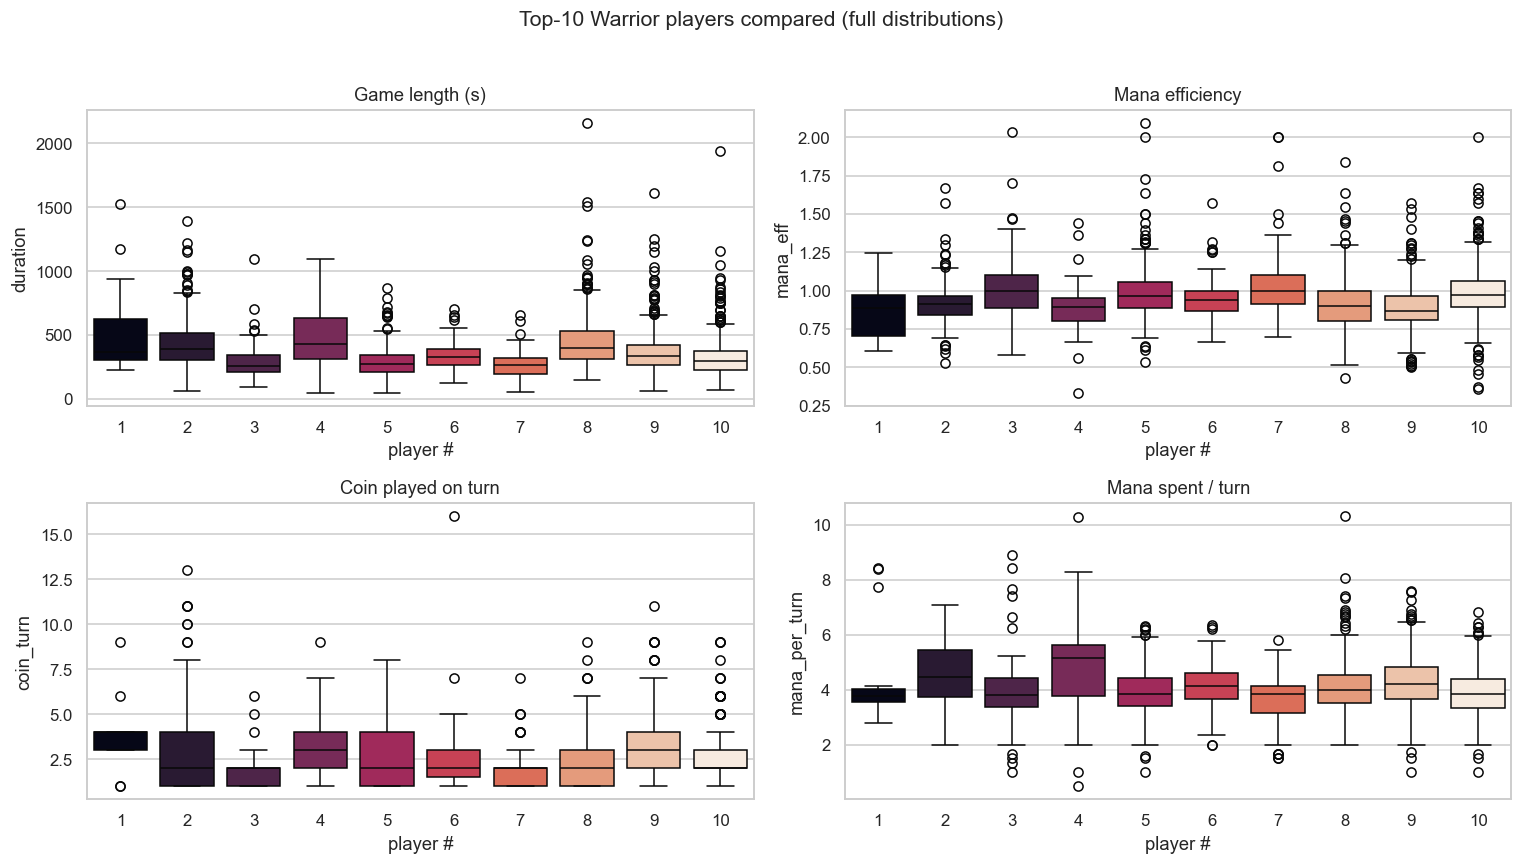

In [15]:
sub = games_df[games_df.user_hash.isin(TOP10)].copy()
pos_map = {u: i + 1 for i, u in enumerate(TOP10)}
sub["player"] = sub.user_hash.map(pos_map)

cmp_cols = ["duration", "n_cards", "cards_per_turn", "mana_eff", "first_turn",
            "coin_turn", "time_per_turn", "mana_per_turn"]
comp = sub.groupby("player")[cmp_cols].mean().rename(columns=NICE)
comp.insert(0, "win%", sub.groupby("player")["win"].mean() * 100)

display(comp.style.format("{:.2f}")
        .background_gradient(cmap="rocket_r")
        .set_caption("Mean of each metric across the Top-10 (player # = rank order)"))

# box-plot comparison of full distributions
show = {"duration": "Game length (s)", "mana_eff": "Mana efficiency",
        "coin_turn": "Coin played on turn", "mana_per_turn": "Mana spent / turn"}
fig, axes = plt.subplots(2, 2, figsize=(14, 8)); axes = axes.ravel()
for ax, (col, title) in zip(axes, show.items()):
    sns.boxplot(data=sub, x="player", y=col, hue="player", palette="rocket",
                legend=False, ax=ax)
    ax.set_title(title); ax.set_xlabel("player #")
fig.suptitle("Top-10 Warrior players compared (full distributions)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()